# 1- Librairies

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
sns.set()

# 2 - Chargement des données

In [4]:
df = pd.read_csv('analyse_final.csv')

In [5]:
df.head()

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,continent,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
0,Afrique du Sud,143.0,2118.0,63.0,514.0,1667.0,57009756,Afrique,-0.28,9353.5520,14591.0,41.38,6.90
1,Albanie,85.0,47.0,0.0,38.0,13.0,2884169,Europe,0.38,1603.5340,14155.0,0.55,3.91
2,Algérie,22.0,277.0,0.0,2.0,275.0,41389189,Afrique,-0.92,1340.3900,15428.0,0.77,5.04
3,Allemagne,71.0,1739.0,646.0,842.0,1514.0,82658409,Europe,0.59,439.8984,61992.0,1138.30,2.76
4,Arabie saoudite,151.0,1435.0,10.0,722.0,616.0,33101178,Asie,-0.58,4694.5000,57943.0,17.10,-0.82


In [6]:
print(f"Le DataFrame utilisé pour notre analyse comporte {df.shape[0]} observations et {df.shape[1]} colonnes.")

Le DataFrame utilisé pour notre analyse comporte 108 observations et 13 colonnes.


In [7]:
print(f"Il a été préparé dans un différent notebook. Il a déjà été nettoyé et comporte {df.duplicated().sum()} doublons et {df.isnull().sum().sum()} valeurs nulles.")

Il a été préparé dans un différent notebook. Il a déjà été nettoyé et comporte 0 doublons et 0 valeurs nulles.


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   pays                                     108 non-null    object 
 1   volailles_dispo_alimentaire_kcal_pers_j  108 non-null    float64
 2   volailles_dispo_interieure               108 non-null    float64
 3   volailles_exportations                   108 non-null    float64
 4   volailles_importations                   108 non-null    float64
 5   volailles_production                     108 non-null    float64
 6   population                               108 non-null    int64  
 7   continent                                108 non-null    object 
 8   stabilite_politique                      108 non-null    float64
 9   distance                                 108 non-null    float64
 10  pib_habitant                             108 non-n

In [16]:
print("Voyons combien il y a de valeurs différentes par colonne.")
print(df.nunique())

Voyons combien il y a de valeurs différentes par colonne.
pays                                       108
volailles_dispo_alimentaire_kcal_pers_j     82
volailles_dispo_interieure                 100
volailles_exportations                      48
volailles_importations                      72
volailles_production                        97
population                                 108
continent                                    5
stabilite_politique                         91
distance                                   108
pib_habitant                               108
surface_bio_1000_ha                        107
inflation_alimentaire                      104
dtype: int64


In [18]:
df.describe()

,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
count,108.000000,108.000000,108.000000,108.000000,108.000000,1.080000e+02,108.000000,108.000000,108.000000,108.000000,108.000000
mean,80.064815,986.462963,157.064815,114.750000,1049.546296,5.785029e+07,0.047500,5447.720224,29163.574074,630.455940,3.552222
std,52.294864,2687.355499,568.670219,210.070844,3063.828530,1.906492e+08,0.847008,4237.028510,23813.179800,3454.585263,5.323107
min,2.000000,3.000000,0.000000,0.000000,0.000000,7.145800e+04,-2.410000,262.384500,1520.000000,0.014000,-3.330000
25%,46.250000,54.750000,0.000000,3.000000,47.250000,4.545160e+06,-0.500000,1703.522500,10827.250000,5.675000,0.395000
50%,71.000000,175.500000,4.000000,26.000000,145.500000,1.054128e+07,0.125000,4725.444000,20949.000000,46.630000,2.350000
75%,107.500000,913.000000,44.250000,121.500000,963.500000,3.875653e+07,0.660000,8834.350250,44575.750000,258.550000,4.205000
max,234.000000,18266.000000,4223.000000,1069.000000,21914.000000,1.421022e+09,1.590000,19263.880000,132170.000000,35645.040000,33.010000


# 3 - Préparation des données

Nous allons à présent séparer les données.

Commençons par préparer la matrice des données.

In [23]:
features = [
    'volailles_dispo_alimentaire_kcal_pers_j',
    'volailles_dispo_interieure',
    'volailles_exportations',
    'volailles_importations',
    'volailles_production',
    'population',
    'stabilite_politique',
    'distance',
    'pib_habitant',
    'surface_bio_1000_ha',
    'inflation_alimentaire'
]

X = df[features].values

In [25]:
print(type(X))
print(f"X est de type np.array.")

<class 'numpy.ndarray'>
X est de type np.array.


In [27]:
print(f"C'est une matrice de {X.shape[0]} lignes et {X.shape[1]} colonnes.")

C'est une matrice de 108 lignes et 11 colonnes.


Les noms des différents pays, les individus de notre analyse, seront stockés dans la variable names.

In [30]:
names = df['pays'].values

Et nous avons précédemment stocké  les noms des colonnes dans la variables features.

In [33]:
for colonne in features:
    print(colonne)

volailles_dispo_alimentaire_kcal_pers_j
volailles_dispo_interieure
volailles_exportations
volailles_importations
volailles_production
population
stabilite_politique
distance
pib_habitant
surface_bio_1000_ha
inflation_alimentaire


Nous sommes à présent prêt à effectuer notre ACP

# 4 - ACP

## 4.1 Standardisation

In [38]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

Il nous faut une moyenne à 0 et un écart type à 1

In [41]:
idx = ['mean', 'std']
pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8,9,10
mean,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [43]:
pd.DataFrame(X_scaled, columns=features).describe().round(2).loc[idx, :]

,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
mean,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 4.2 ACP

Nous allons travailler que sur l'ensemble des composantes : 

In [47]:
n_components = len(features)

In [49]:
pca = PCA(n_components=n_components)
pca.fit(X_scaled)

PCA(n_components=11)

In [51]:
pca.explained_variance_ratio_

array([3.03870969e-01, 1.83849511e-01, 1.31400038e-01, 9.04525647e-02,
       7.99444108e-02, 7.77861903e-02, 6.02137979e-02, 3.94365285e-02,
       1.99918822e-02, 1.30160518e-02, 3.80553727e-05])

In [60]:
scree = (pca.explained_variance_ratio_ * 100).round(2)

In [62]:
scree

array([30.39, 18.38, 13.14,  9.05,  7.99,  7.78,  6.02,  3.94,  2.  ,
        1.3 ,  0.  ])

In [64]:
print(f"La première composante capte donc {scree[0]} % de la variance. Les deux premières {(scree[0] + scree[1])} %.")

La première composante capte donc 30.39 % de la variance. Les deux premières 48.769999999999996 %.


Calculons à présent la somme calculée des composantes.

In [67]:
scree_cum = scree.cumsum().round()

Définisons une variable avec la liste de nos composantes:

In [70]:
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [72]:
print('Variance par composante :')
for i, sc, cum in zip(x_list ,scree, scree_cum):
    print(f'  F{i} : {sc}%  (cumulé : {cum}%)')

Variance par composante :
  F1 : 30.39%  (cumulé : 30.0%)
  F2 : 18.38%  (cumulé : 49.0%)
  F3 : 13.14%  (cumulé : 62.0%)
  F4 : 9.05%  (cumulé : 71.0%)
  F5 : 7.99%  (cumulé : 79.0%)
  F6 : 7.78%  (cumulé : 87.0%)
  F7 : 6.02%  (cumulé : 93.0%)
  F8 : 3.94%  (cumulé : 97.0%)
  F9 : 2.0%  (cumulé : 99.0%)
  F10 : 1.3%  (cumulé : 100.0%)
  F11 : 0.0%  (cumulé : 100.0%)


## 4.2 Éboulis des valeurs propres

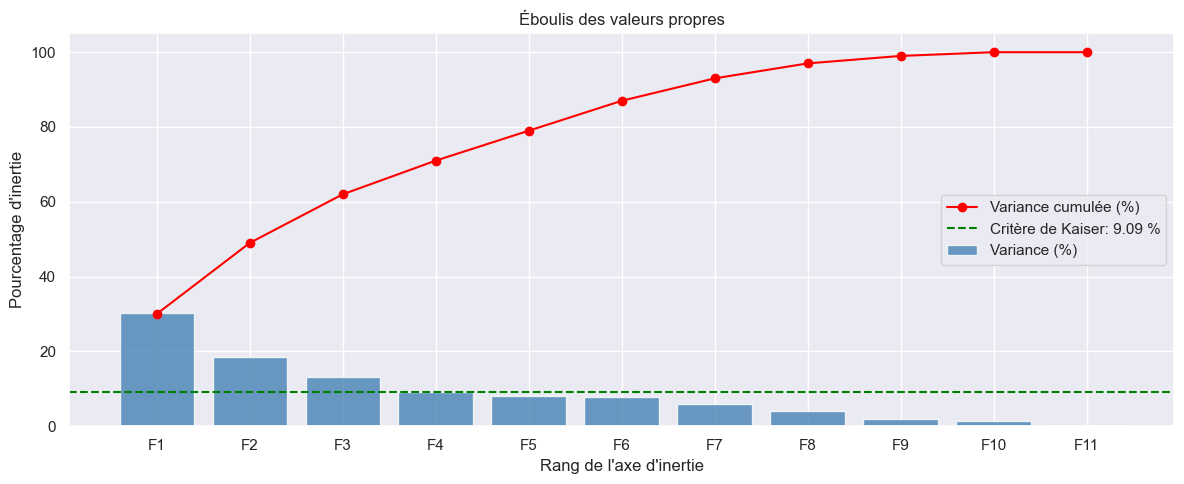

In [75]:
kaiser = 100 / n_components

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x_list, scree, color='steelblue', alpha=0.8, label='Variance (%)')
ax.plot(x_list, scree_cum, c="red", marker='o', label='Variance cumulée (%)')
ax.axhline(y=kaiser, color='green', linestyle='--', label=f'Critère de Kaiser: {round(kaiser, 2)} %')

ax.set_xlabel("Rang de l'axe d'inertie")
ax.set_ylabel("Pourcentage d'inertie")

ax.set_xticks(list(x_list))
ax.set_xticklabels([f'F{i}' for i in x_list])


ax.legend(loc='center right')

plt.title('Éboulis des valeurs propres')
plt.tight_layout()
plt.show()

On a en bleu la variance de chaque nouvelle composante, et en rouge la variance cumulée. On peut voir que seule les 4 premières composantes satisfont le critère de Kaiser (en vert). Ces 5 composantes contiennent 85% de la variance.

## 4.3 Components

Regardons à présent nos composantes.

In [80]:
pcs = pca.components_
pcs

array([[ 2.46820330e-01,  5.17169807e-01,  4.18569943e-01,
         1.83488393e-01,  5.20062725e-01,  3.32117929e-01,
         4.96417663e-02,  5.80740351e-02,  2.08072267e-01,
         1.18606870e-01, -1.37040924e-01],
       [-3.29680287e-01,  1.72284786e-01,  4.52327576e-02,
        -1.46627320e-01,  1.66253013e-01,  2.90522827e-01,
        -5.67578407e-01,  1.62508524e-01, -5.28577046e-01,
        -1.21775483e-01,  2.88552387e-01],
       [ 3.67368992e-01, -4.68755812e-02, -3.03034686e-02,
        -2.74582951e-01, -2.77435087e-02, -1.18836797e-01,
         9.23600058e-02,  6.80541610e-01, -2.43396297e-01,
         4.90572471e-01,  8.14615243e-03],
       [ 2.85181259e-01, -1.09359984e-03,  4.98120268e-01,
        -4.13178521e-01,  1.17235928e-01, -4.63994312e-01,
         3.82945205e-02, -1.83401611e-01, -6.45174626e-02,
        -3.10824671e-01,  3.67311964e-01],
       [-4.00801825e-02,  5.46782717e-03, -6.33118413e-02,
         1.69125607e-01, -1.70083359e-02,  4.16137010e-02,
  

Mettons les dans un DataFrame.

In [83]:
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8,9,10
0,0.246820,0.517170,0.418570,0.183488,0.520063,0.332118,0.049642,0.058074,0.208072,0.118607,-0.137041
1,-0.329680,0.172285,0.045233,-0.146627,0.166253,0.290523,-0.567578,0.162509,-0.528577,-0.121775,0.288552
2,0.367369,-0.046876,-0.030303,-0.274583,-0.027744,-0.118837,0.092360,0.680542,-0.243396,0.490572,0.008146
3,0.285181,-0.001094,0.498120,-0.413179,0.117236,-0.463994,0.038295,-0.183402,-0.064517,-0.310825,0.367312
4,-0.040080,0.005468,-0.063312,0.169126,-0.017008,0.041614,-0.026334,-0.205959,0.248674,0.531857,0.758886
5,0.322035,-0.033785,0.022106,0.775171,-0.069957,-0.280996,-0.199518,0.229686,-0.176469,-0.252284,0.150230
6,0.025323,-0.073114,0.230937,0.046763,-0.025562,-0.325758,-0.534818,-0.359096,-0.090973,0.494561,-0.404815
7,0.679170,0.013710,-0.420440,-0.217667,-0.061136,0.299462,-0.366616,-0.226241,0.118773,-0.144535,0.019666
8,-0.203771,0.051963,-0.048260,-0.129571,0.042735,-0.251574,-0.438962,0.427256,0.689494,-0.144517,0.004538
9,0.073122,-0.510918,0.564123,0.032193,-0.355896,0.485863,-0.108362,0.124842,0.152104,-0.030703,0.014611


In [85]:
pcs.columns = features
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
F1,0.25,0.52,0.42,0.18,0.52,0.33,0.05,0.06,0.21,0.12,-0.14
F2,-0.33,0.17,0.05,-0.15,0.17,0.29,-0.57,0.16,-0.53,-0.12,0.29
F3,0.37,-0.05,-0.03,-0.27,-0.03,-0.12,0.09,0.68,-0.24,0.49,0.01
F4,0.29,-0.00,0.50,-0.41,0.12,-0.46,0.04,-0.18,-0.06,-0.31,0.37
F5,-0.04,0.01,-0.06,0.17,-0.02,0.04,-0.03,-0.21,0.25,0.53,0.76
F6,0.32,-0.03,0.02,0.78,-0.07,-0.28,-0.20,0.23,-0.18,-0.25,0.15
F7,0.03,-0.07,0.23,0.05,-0.03,-0.33,-0.53,-0.36,-0.09,0.49,-0.40
F8,0.68,0.01,-0.42,-0.22,-0.06,0.30,-0.37,-0.23,0.12,-0.14,0.02
F9,-0.20,0.05,-0.05,-0.13,0.04,-0.25,-0.44,0.43,0.69,-0.14,0.00
F10,0.07,-0.51,0.56,0.03,-0.36,0.49,-0.11,0.12,0.15,-0.03,0.01


Lire nos résultat est plus facile quand ils sont présentés sous la forme d'un DataFrame plutôt que sous celle d'un np.array. Mais nous n'avons pas besoin d'analyser toutes nos composantes. En effet, en s'appuyant sur le critère de Kaiser et sur la méthode du coude, nous décidons de ne garder que 5 composantes pour la suite de notre analyse.

In [88]:
n_comp = 6

pca = PCA(n_components=n_comp)
pca.fit(X_scaled)
X_proj = pca.transform(X_scaled)

print(f"Variance expliquée par les {n_comp} premières composantes:")
for i in range(n_comp):
    print(f"F{i+1} : {pca.explained_variance_ratio_[i] * 100 : .2f} %")
print(f"Total : {pca.explained_variance_ratio_.sum() * 100 : .2f} %")

Variance expliquée par les 6 premières composantes:
F1 :  30.39 %
F2 :  18.38 %
F3 :  13.14 %
F4 :  9.05 %
F5 :  7.99 %
F6 :  7.78 %
Total :  86.73 %


In [90]:
pcs = pca.components_
pcs = pd.DataFrame(pcs, columns = features, index = [f'F{i+1}' for i in range(n_comp)])
pcs.round(2)

,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
F1,0.25,0.52,0.42,0.18,0.52,0.33,0.05,0.06,0.21,0.12,-0.14
F2,-0.33,0.17,0.05,-0.15,0.17,0.29,-0.57,0.16,-0.53,-0.12,0.29
F3,0.37,-0.05,-0.03,-0.27,-0.03,-0.12,0.09,0.68,-0.24,0.49,0.01
F4,0.29,-0.00,0.50,-0.41,0.12,-0.46,0.04,-0.18,-0.06,-0.31,0.37
F5,-0.04,0.01,-0.06,0.17,-0.02,0.04,-0.03,-0.21,0.25,0.53,0.76
F6,0.32,-0.03,0.02,0.78,-0.07,-0.28,-0.20,0.23,-0.18,-0.25,0.15


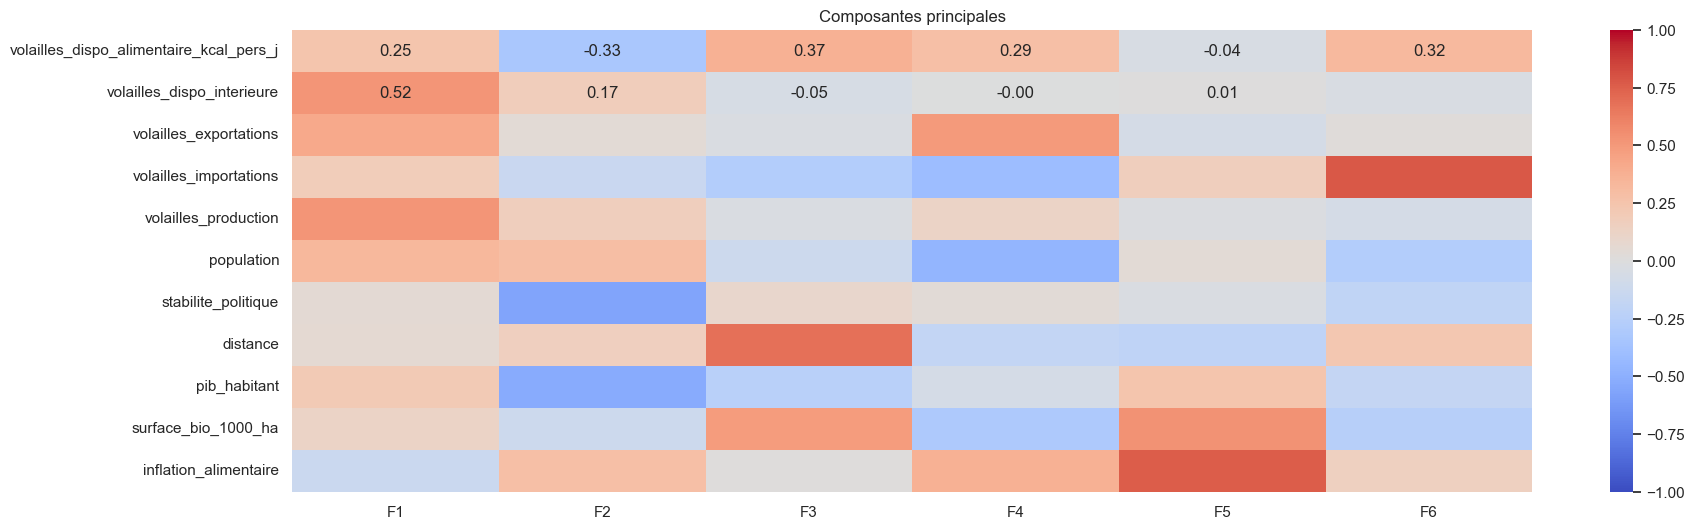

In [92]:
fig, ax = plt.subplots(figsize=(20, 6))

sns.heatmap(pcs.T, vmin = -1, vmax = 1, annot = True, cmap = 'coolwarm', fmt = '0.2f')

plt.title('Composantes principales')
plt.show()

**Observations**

- Les principales contributions à F1 sont, dans l'ordre décroissant de la force, volailles_dispo_interieure, volailles_production, volailles_exportations et volailles_dispo_alimentaire_kcal_pers_j pour les contribution positives.
- Les principales contributions à F2 sont, dans l'ordre décroissant de la force, inflation_alimentaire, population et distance pour les contributions positives, stabilite_politique et pib_habitant pour les contributions négatives.
-  Les principales contributions à F3 sont, dans l'ordre décroissant de la force, distance et surface_bio_1000_ha pour les contributions positives, volailles_importations et pib_habitant pour les contributions négatives.
-  Les principales contributions à F4 sont, dans l'ordre décroissant de la force, volailles_exportations, volailles_dispo_alimentaire_kcal_pers_j et inflation_alimentaire pour les contribution positives, volailles_importations, population et surface_bio_1000_ha pour les contributions négatives.
-  Les principales contributions à F5 sont, dans l'ordre décroissant de la force, inflation_alimentaire et surface_bio_1000_ha pour les contributions positives, la distance pour les contributions négatis.
ves.


## 4.4 Cercle des corrélations

In [96]:
def correlation_graph(pca, x_y, features) : 

    x,y = x_y

    fig, ax = plt.subplots(figsize=(10, 9))

    for i in range(0, pca.components_.shape[1]):
        ax.arrow(0,0, 
                pca.components_[x, i],  
                pca.components_[y, i],  
                head_width=0.07,
                head_length=0.07, 
                width=0.02, )


        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])
        
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  

    plt.axis('equal')
    plt.show(block=False)

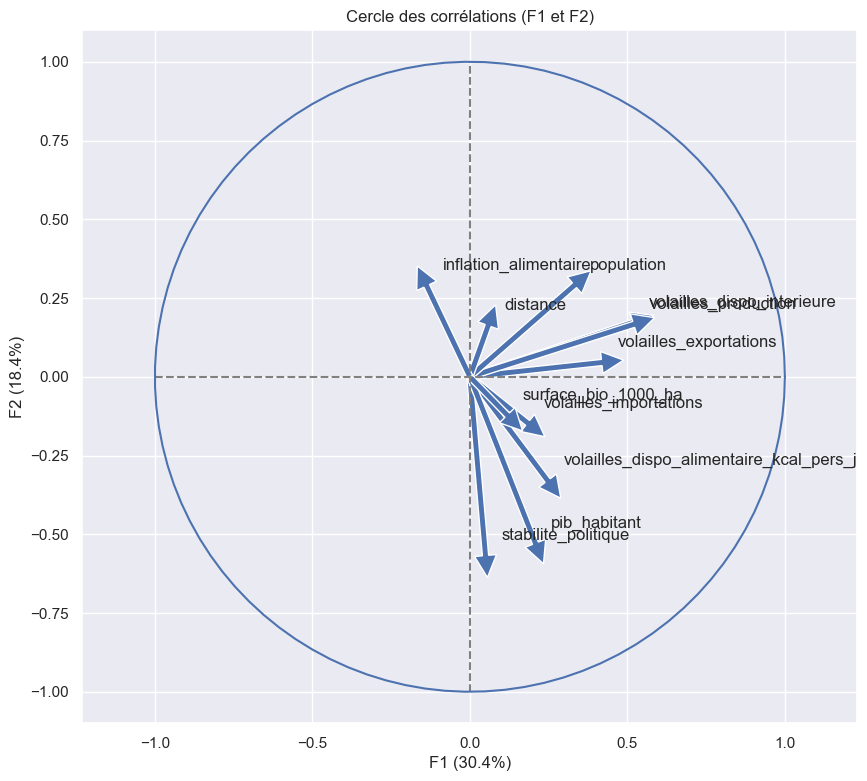

In [100]:
# Plan F1 / F2
correlation_graph(pca, (0, 1), features)

**Interprétation de F1 (30.4%)**


Variables corrélées positivement à F1 (flèches vers la droite) : 
- volailles_dispo_interieure
- volailles_exportations
- volailles_importations
- population


Il ne semble pas y avoir de variables corrélées négativement à F1.


On peut supposer que F1 représente l'activité de la filière volaille d'un pays. Plus un pays est à droite de notre graphique, plus sa filière volaille est développée.


**Interprétation de F2 (18.4%)**


Variables corrélées positivement à F2 (flèches vers le haut) :
- inflation_alimentaire
- population
- distance


Variables corrélées négativement à F2 (flèches vers le bas) :
- stabilite_politique
- pib_habitant


On peut supposer que F2 est lié au niveau de développement économique d'un pays. Les pays en haut du graphique sont plus éloignés, moins stable et connaissent une forte inflation, tandis que les pays en bas du graphique ont tendance à être plus riches et stables politiquement.




**Points d'attention**


surface_bio_1000_ha, distance et inflation_alimentaire ont des flèches très courtes. Elles ne sont pas bien représentées sur ce plan. Mieux vaut éviter de tirer des conclusions en se basant sur ces variables, dans ce plan.


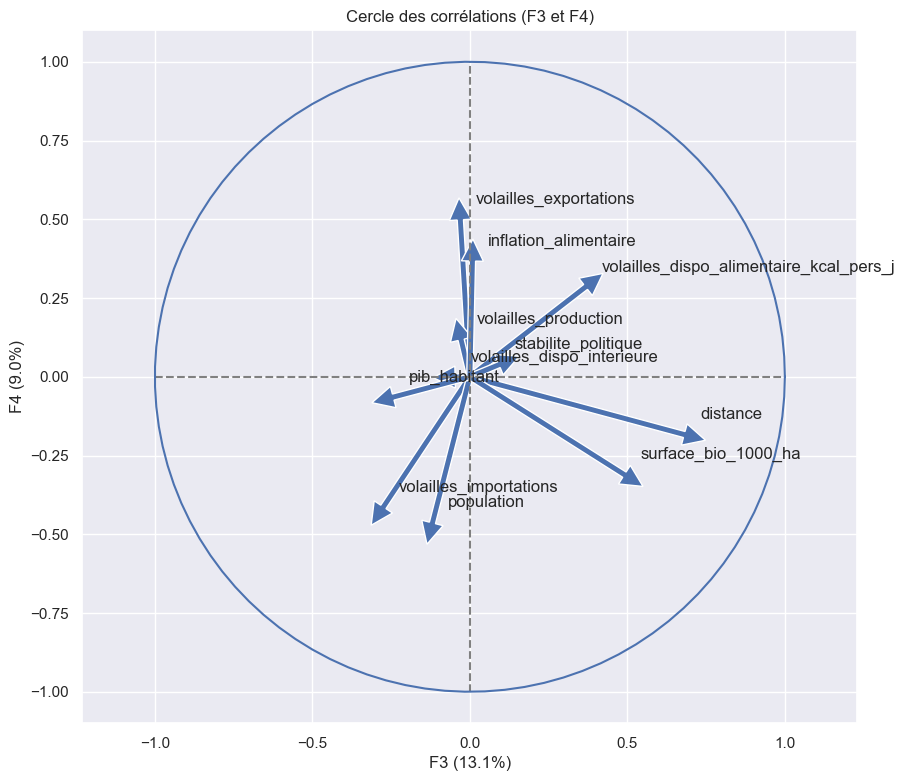

In [103]:
# Plan F3 / F4
correlation_graph(pca, (2, 3), features)

**Interprétation de F3 (13.1%)**

Variables corrélées positivement à F3 (flèches vers la droite):
- distance
- surface_bio_1000_ha
- volailles_dispo_alimentaire_kcal_pers_j

Variables corrélées négativement à F3 (flèches vers la gauche) :
- volailles_importations
- pib_habitant

F3 semble lié à l'éloignement de la France et au développement de la filière bio. Les pays situés à droite du graphique sont loin de la France, ont une grande surface dédiées à l'agriculture biologique, ont une plus importante disponibilité en viande de volaille par personne et ont donc tendance à moins en importer. Le PIB par habitant dans ces pays a aussi tendance a être plus faible. Les pays situés à gauche sont plus proche, importent davantage de volailles, et le PIB par habitant y est plus élevé.


**Interprétation de F4 (9.0%)**

Variables corrélées positivement à F4 (flèches vers le haut) :
- volailles_exportations
- inflation_alimentaire

Variables corrélées négativement à F4 (flèches vers le bas) :
- volailles_importations
- population
- surface_bio_1000_ha

F4 semble centré autour du profil exportateur vs importateur des pays. Les pays en haut du graphique exportent davantage et connaissent une forte inflation. Les pays en bas sont de grands importateurs et ont tendance à être plus peuplés.

**Points d'attention**

Les variables distance et surface_bio_1000_ha qui étaient assez mal représentées sur le plan F1 / F2 sont bien représentées dans le plan F3 / F4. Elles  semblent donc apporter une information indépendante des autres variables.

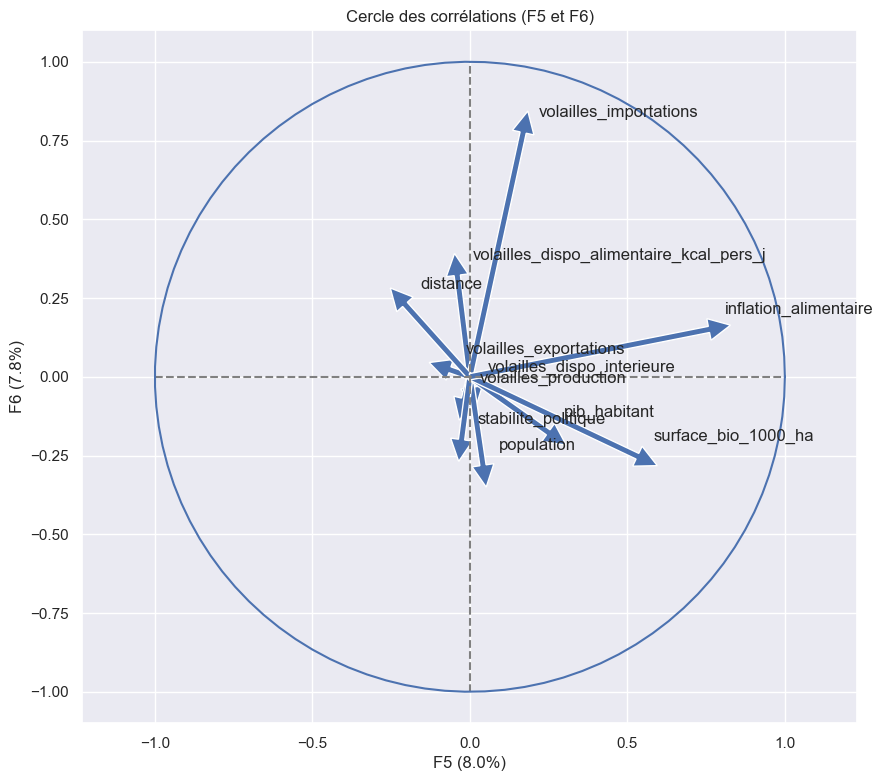

In [106]:
# Plan F5 / F6
correlation_graph(pca, (4, 5), features)

**Interprétation de F5 (8.0%)**


Variables corrélées positivement à F5 (flèches vers la droite):
- inflation_alimentaire
- surface_bio_1000_ha


Variables corrélées négativement à F5 (flèches vers la gauche) :
- distance


On peut supposer que F5 représente l'inflation et le développement de la filière biologique. Les pays situés à droite du graphique connaissent une forte inflation alimentaire mais disposent d'une grande surface dédiée à l'agriculture biologique. Ils sont aussi moins éloignés de la France.


**Interprétation de F6 (7.8%)**


La sixième composante ne remplissait pas le critère de Kaiser. Nous n'allons donc pas nous y intéresser. Nous remarquons néanmoins qu'elle est extrêmement corrélées positivement à l'importation de volaille.


## 4.5 Projection des pays

In [110]:
def display_factorial_planes(   X_projected, 
                                x_y, 
                                pca=None, 
                                labels = None,
                                clusters=None, 
                                alpha=1,
                                figsize=[14,10], 
                                marker="." ):


    X_ = np.array(X_projected)

    if not figsize: 
        figsize = (7,6)

    if  labels is None : 
        labels = []
    try : 
        len(labels)
    except Exception as e : 
        raise e

    if not len(x_y) ==2 : 
        raise AttributeError("2 axes sont demandées")   
    if max(x_y )>= X_.shape[1] : 
        raise AttributeError("la variable axis n'est pas bonne")   

    x, y = x_y

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    c = None if clusters is None else clusters
 
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    if pca : 
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else : 
        v1=v2= ''

    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.5)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.5)

    if len(labels) : 
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='7', ha='center',va='center') 

    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()

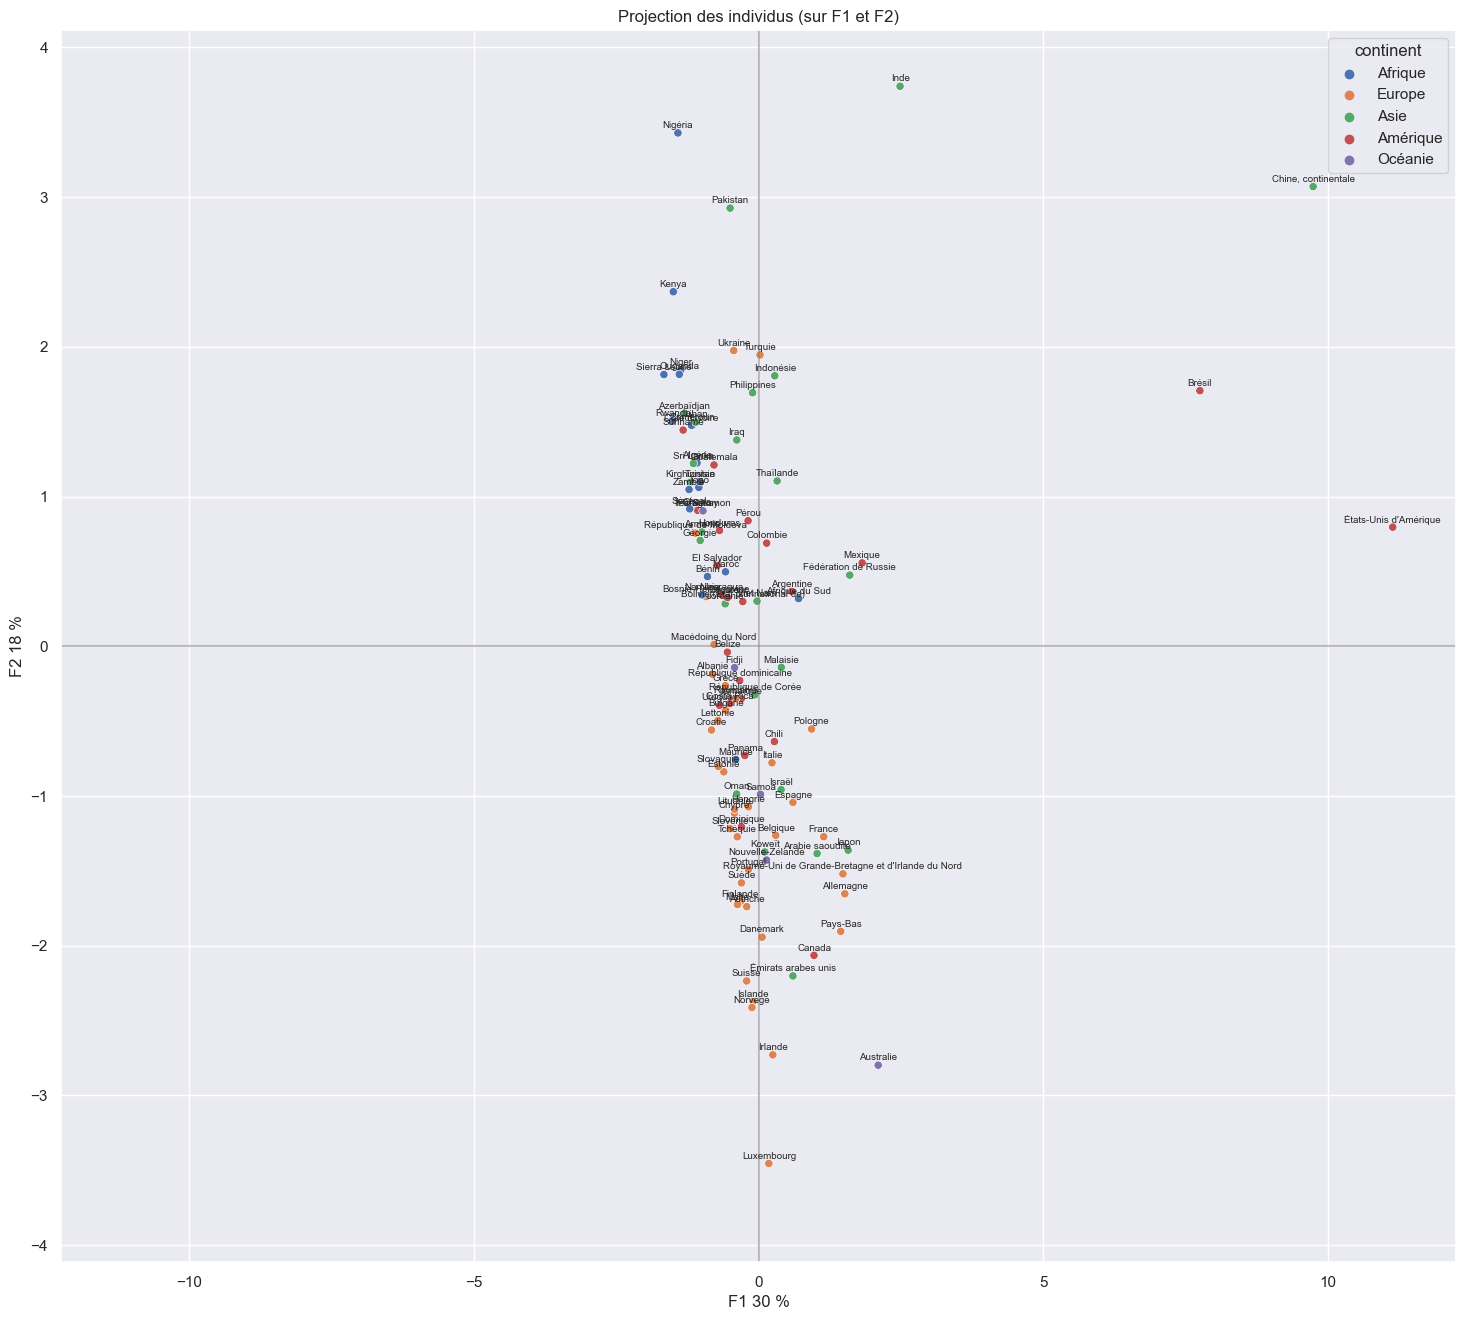

In [112]:
display_factorial_planes(X_proj, 
                         (0, 1), 
                         pca,
                         labels=names,
                         clusters=df['continent'],
                         figsize=(18,16))

**Observations**

On peut déjà dire que le nuage de points est très allongé verticalement (axe F2) et peu étalé horizontalement (axe F1). On note aussi la présence d'outliers à droite.

**Lecture de l'axe F1 (activité de la filière volaille):**
- On trouve à droite les outliers que nous avons mentionnés plus haut. Il s'agit des Etats-Unis, de la Chine et du Brésil. Ce sont des pays ayant une filière volaille très développée.
- L'immense majorité des pays se trouvent au centre. Le développement de l'activité lié à la volaille dans ces pays est dans la norme.
- On ne trouve pas à gauche des outliers comme on en trouve à droite. Certains pays sont néanmoins un peu plus en marge que les autres, comme le Nigeria, le Sierra Leone ou le Kenya.

**Lecture de l'axe F2 (développement économique inversé):**
- On trouve en haut des pays en développement économique avec une inflation élevée et instables politiquement (Inde, Nigeria, Pakistan)
- En bas se trouvent plutôt des pays riches, stables politiquement, avec une faible inflation (Luxembourg, Australie)

**Conclusion:**
Dans le cadre de notre étude, et en se basant sur ce plan, ce sont les pays situés au centre bas ou à la rigueur au centre gauche qui devraient être les plus susceptibles de nous intéresser. Soit des pays riches, stables avec un pouvoir d'achat élevé, n'ayant pas une filière de la viande de volaille trop développée (mais pas trop peu développée non plus, ce qui pourrait être la conséquence d'un manque d'intérêt de la population pour cette limentation).


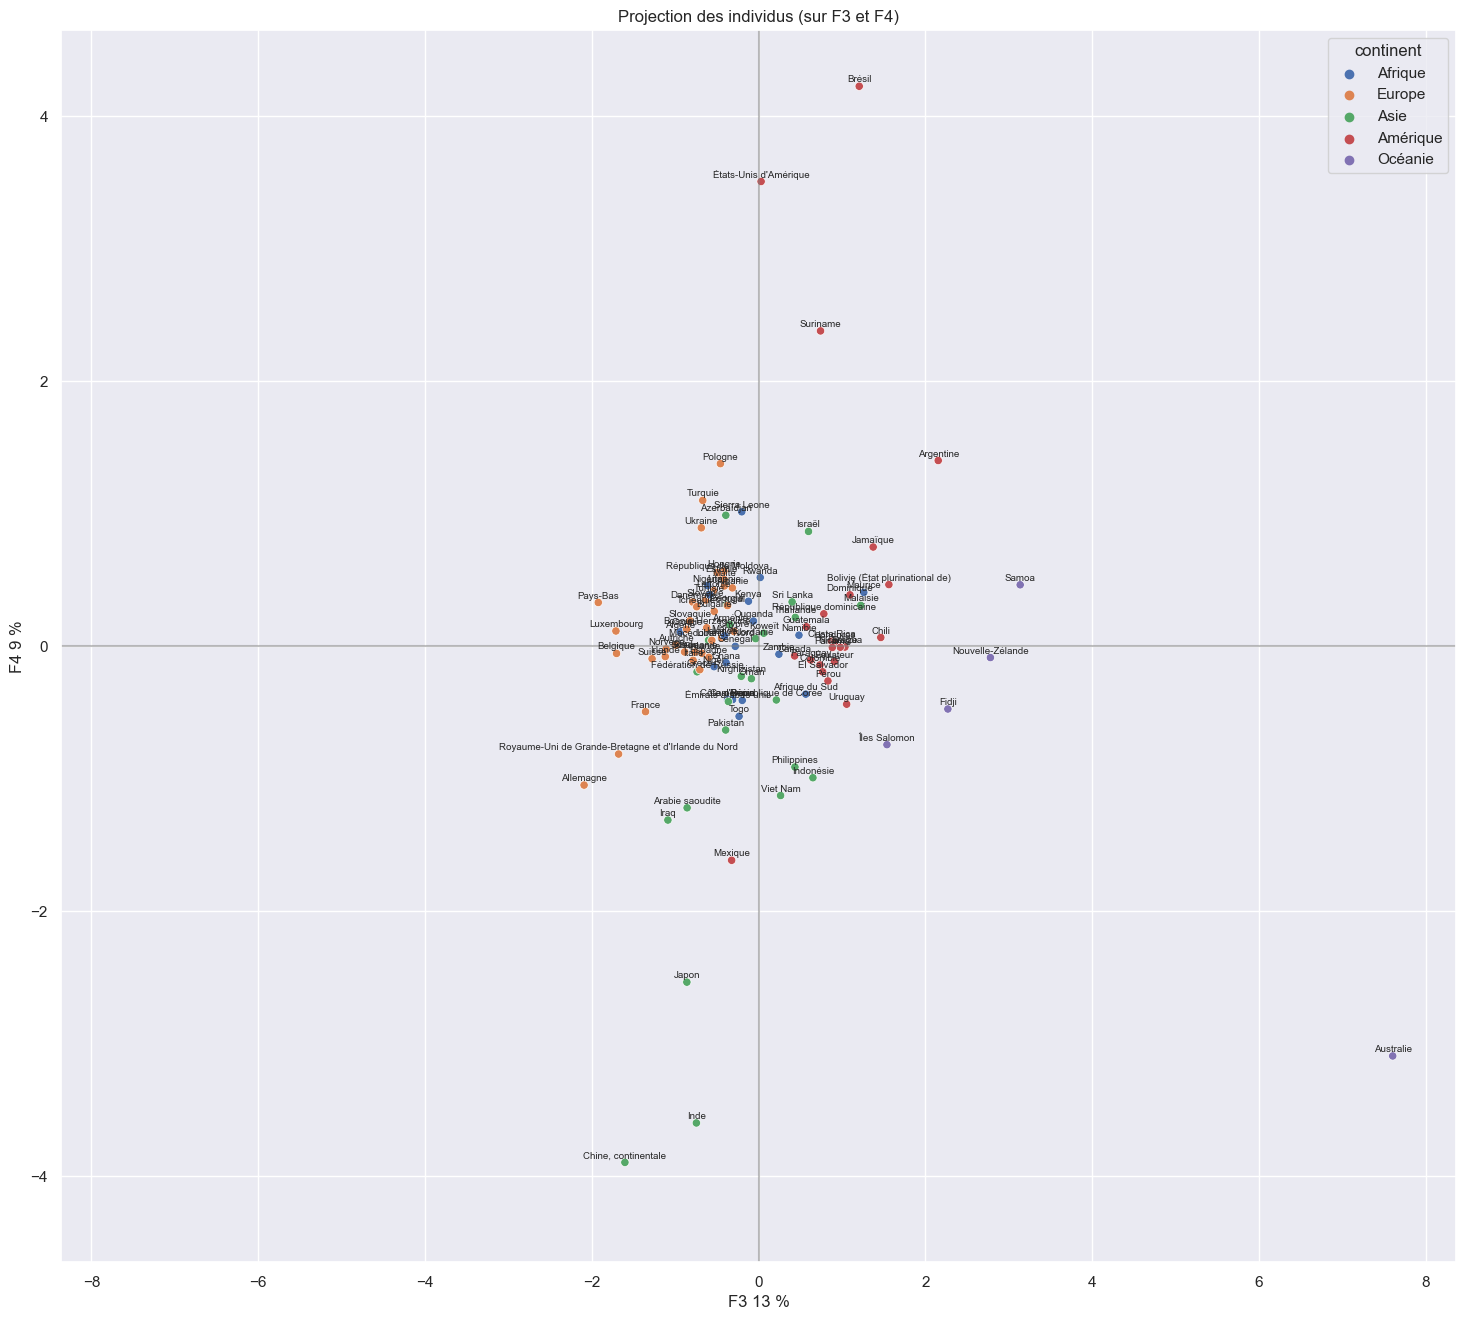

In [114]:
display_factorial_planes(X_proj, 
                         (2, 3), 
                         pca,
                         labels=names,
                         clusters=df['continent'],
                         figsize=(18,16))

**Observations**

Le nuage de points est cette fois bien plus centré que dans le plan précédent, que l'on regarde l'axe horizontal ou l'axe vertical. On peut néanmoins voir quelques outliers, principalement sur l'axe vertical.

**Lecture de l'axe F3 (éloignement et développement de la filière bio):**
- Les pays situés à droite de ce graphique sont très éloignés de la France et ont une agriculture bio développée.
- La très grande majorité des pays se trouvent au centre, avec une distance de la France moyenne et une surface dédiée à l'agriculture biologique moyenne.
- Les pays situés à gauche du graphique sont proches de la France, et semblent avoir développé peu de surface dédiée à l'agriculture biologique. On y trouve le Royaume-Uni, l'Allemagne, les Pays-Bas ou le Luxembourg.

**Lecture de l'axe F4 (profil exportateur / importateur des pays):**
- On trouve en haut du graphique les grands pays exportateurs de volaille (Brésil, États-Unis, Suriname, Argentine).
- Au centre les pays avec un équilibre import/export de ce produit.
- Les grands importateurs ou consommateurs de volaille se trouvent donc en bas (Chine, Inde, Japon, Mexique, Australie, Allemagne).

**Conclusion:**
Dans le cadre de notre étude, et en se basant sur ce plan, ce sont les pays situés en bas et à gauche qui devraient être les plus susceptibles de nous intéresser. Ceux situés en bas au centre présentent aussi un intérêt (importateur et sensibles à l'agriculture biologique). Ces pays sont de grands importateurs de volailles, et se situent près de la France. À l'inverse, les pays situés en haut du graphique sont nos concurrents.


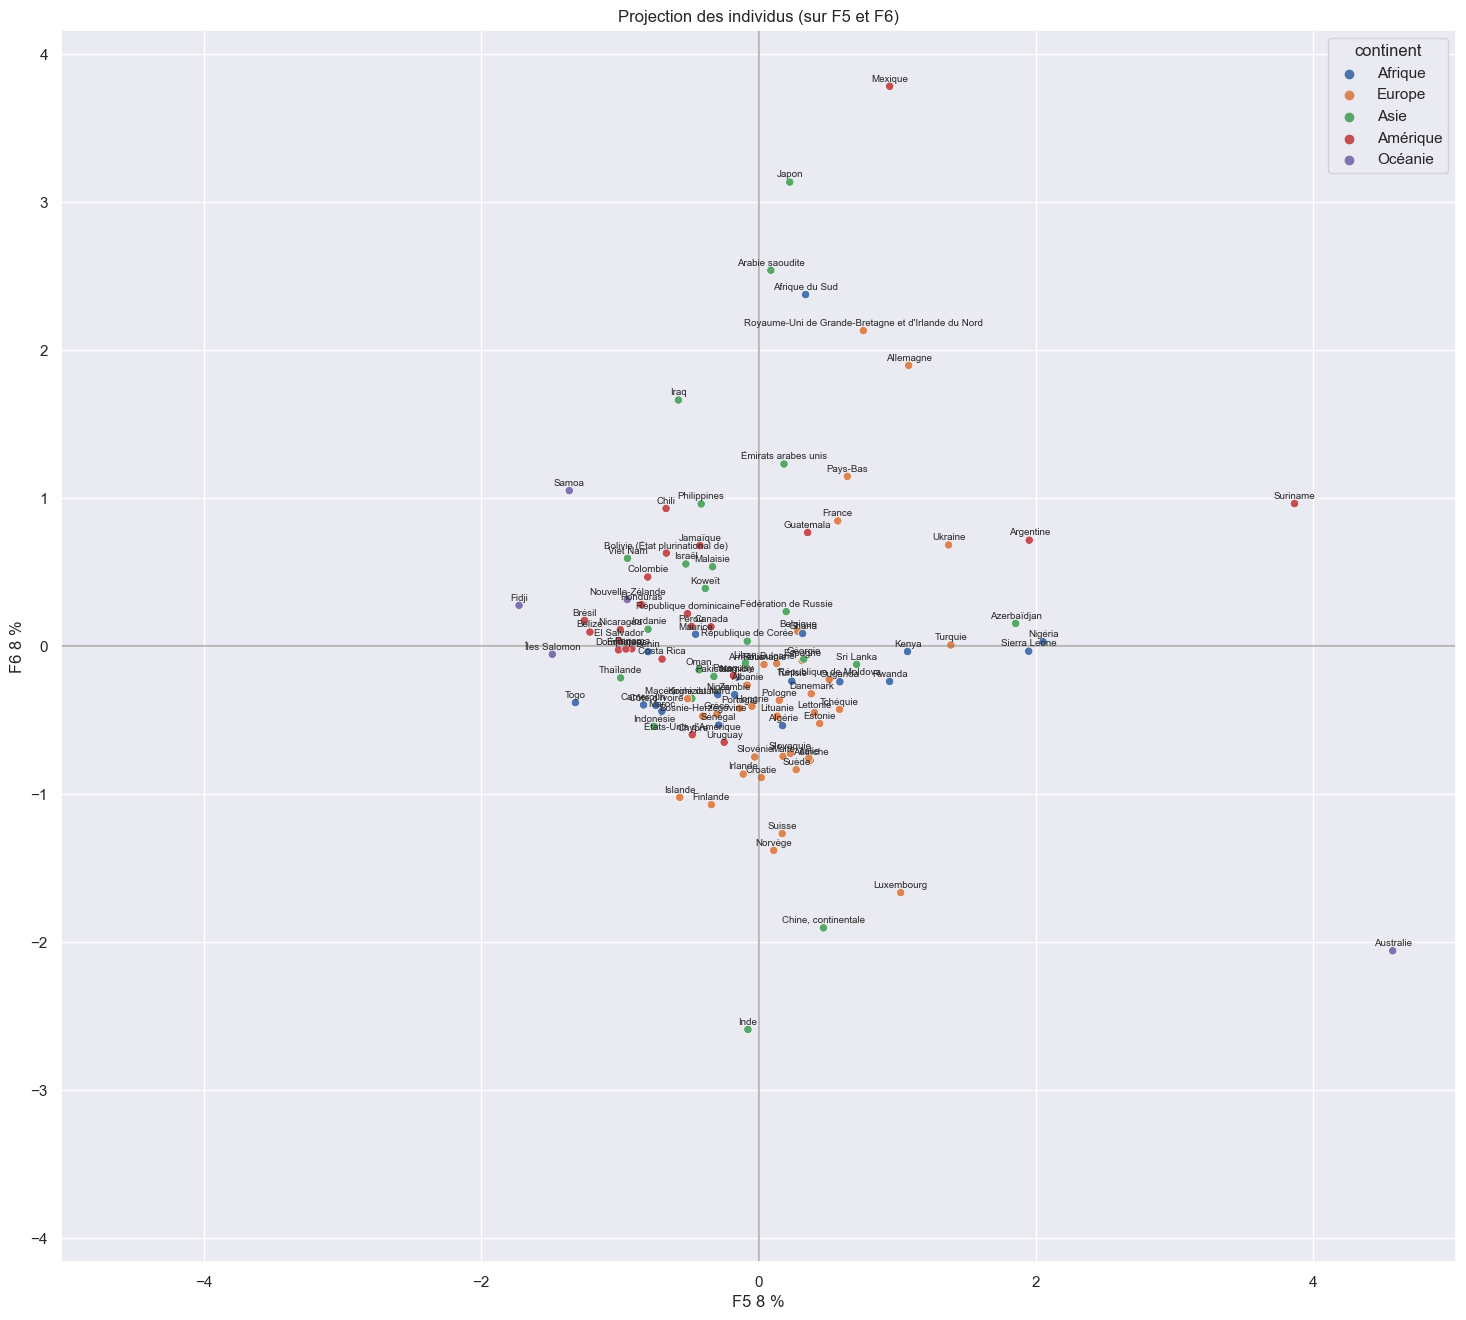

In [117]:
display_factorial_planes(X_proj, 
                         (4, 5), 
                         pca,
                         labels=names,
                         clusters=df['continent'],
                         figsize=(18,16))

**Observations**

Là encore, le nuage de points est plutôt centré bien qu'un peu étalé sur l'axe des ordonnées. On voit aussi quelques outliers sur la droite du graphique.

**Lecture de l'axe F5 (inflation et développement de la filière biologique):**
- Les pays situés à droite de ce graphique ont connu une forte inflation alimentaire en 2017, et avaient grande surface dédiée à l'agriculture biologique (Australie, Suriname, Argentine)
- La grande majorité des pays se trouvent là aussi au centre. Ils présentent donc un profil "moyen" regardant cette composante.
- Les pays situés à gauche du graphique ont connu une faible inflation, et présentent peu de surface bio.

**Lecture de l'axe F6 (importation de volaille):**

Nous n'allons pas nous intéresser de trop près à la lecture de cet axe. Les pays situés en haut de ce graphique sont néanmoins de grands importateurs de volailles (Mexique, Japon, Arabie saoudite, Afrique du Sud, Royaume-Uni, Allemagne)

**Conclusion et synthèse:**

La lecture et l'analyse de nos cercles des corrélations et de la projections des individus nous permet de nous faire une meilleure idée du profil idéal de nos pays à cibler. Il s'agit de pays n'ayant pas une industrie de la filière volaille trop ou trop peu développée (F1 centre), riche et stable (F2 bas), proche de la France (F3 gauche), grand importateur de volaille (F4 bas et F6 haut), et sensible à l'agriculture biologique (F3/F5 élevé).

Des pays correspondant à ce profil seraient l'Allemagne, les Pays-Bas, le Royaume-Uni ou la Belgique en Europe, l'Arabie saoudite ou les Émirats arabes unis au Moyen-Orient (le Japon aurait aussi un profil idéal, mais il est probablement situé un peu trop lon).


# 5 - Clustering

## 5.1 Classification ascendante hiérarchique (ou CAH)

Commençons par calculer les distances avec la méthode de Ward

In [125]:
Z = linkage(X_scaled, method="ward")

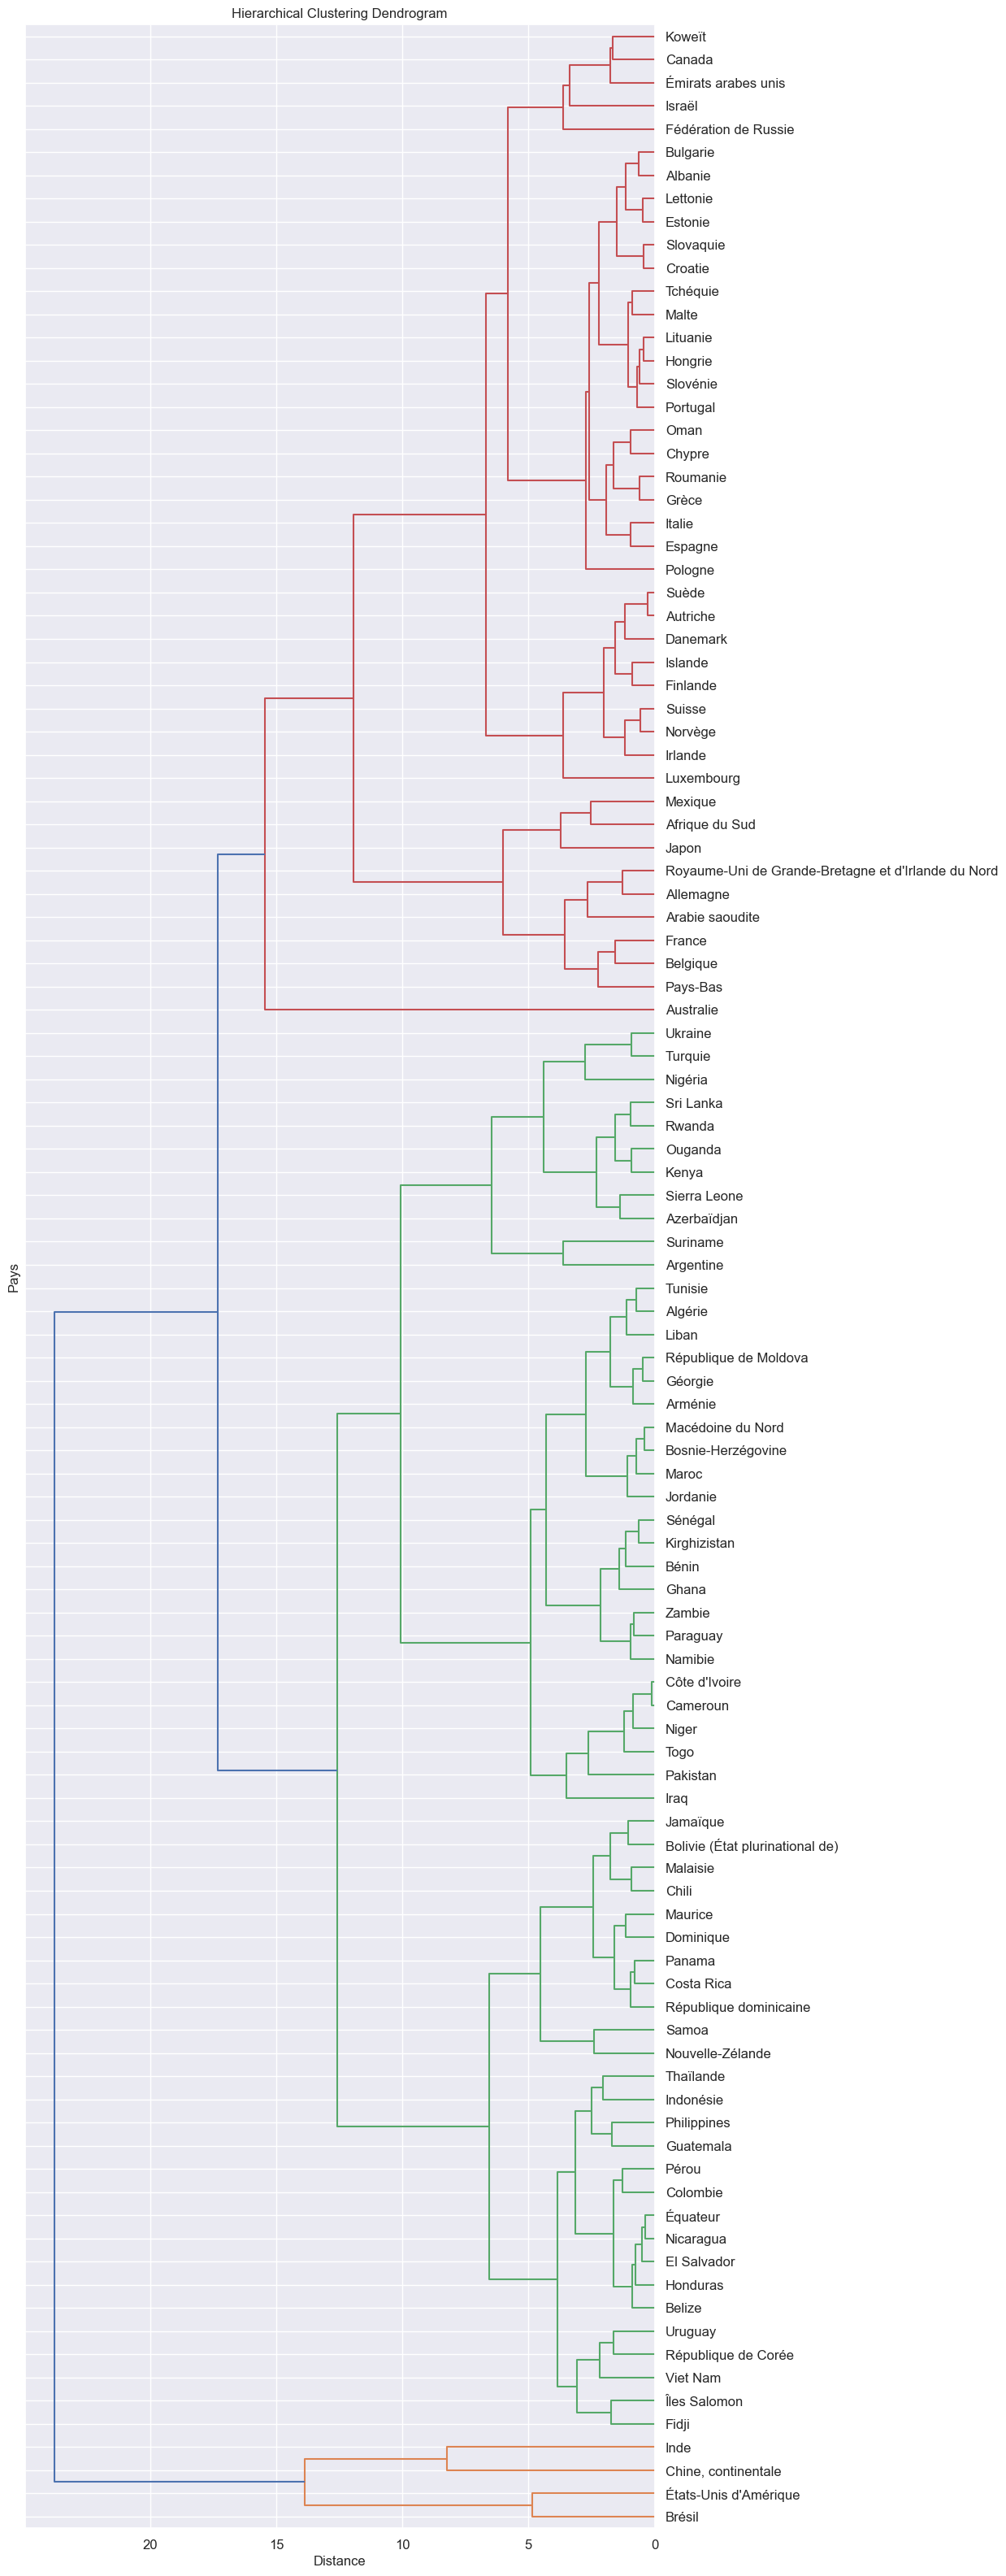

In [127]:
fig, ax = plt.subplots(1, 1, figsize=(10,40))

full_den = dendrogram(Z, ax=ax, labels=names, orientation = "left")

plt.title("Hierarchical Clustering Dendrogram")
ax.set_xlabel("Distance")
ax.set_ylabel("Pays")
ax.tick_params(axis='x', which='major', labelsize=12)
ax.tick_params(axis='y', which='major', labelsize=12)

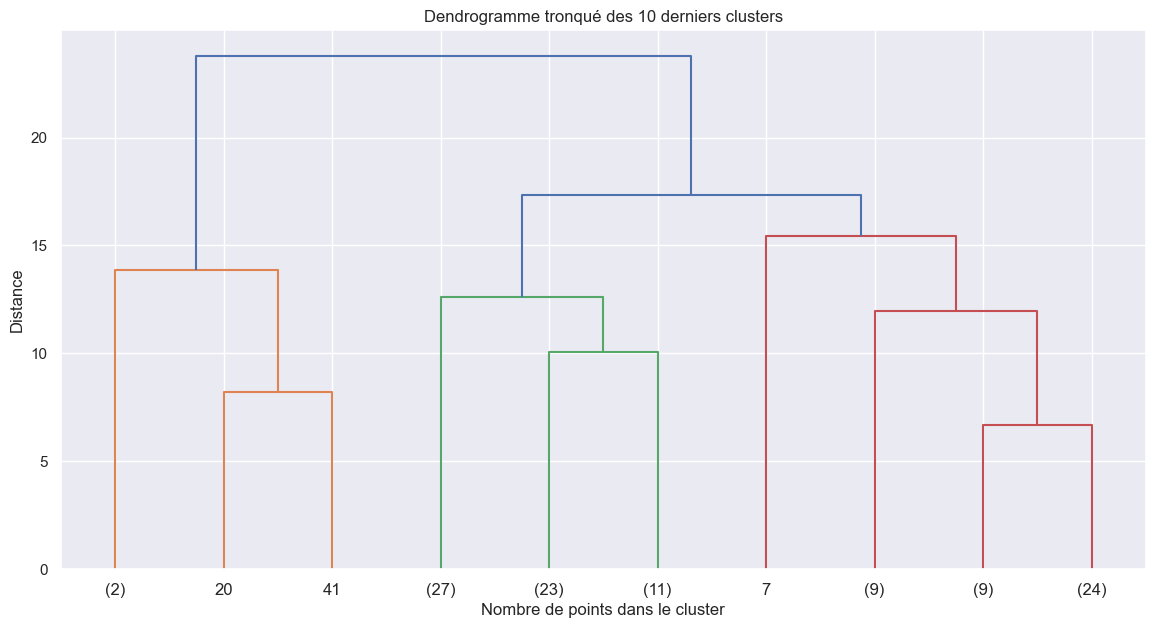

In [128]:
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
dendrogram(Z, ax=ax, p=10, truncate_mode='lastp')
ax.set_title('Dendrogramme tronqué des 10 derniers clusters')
ax.set_xlabel('Nombre de points dans le cluster')
ax.set_ylabel('Distance')

plt.show()

On observe 3 grandes branches colorées qui se séparent à une distance élevée (à peu près 17 ou 18). Nous allons choisr de travailler avec 5 clusters, pour avoir des groupes ni trop fin, ni trop grossier. La séparation en 5 clusters a lieu à une distance d'à peu près 13.

In [131]:
k_cah = 5

labels_cah = fcluster(Z, k_cah, criterion='maxclust')

In [133]:
labels_cah

array([4, 4, 3, 4, 4, 3, 3, 5, 4, 3, 4, 3, 3, 3, 1, 4, 3, 3, 4, 3, 2, 4,
       3, 3, 4, 3, 4, 3, 3, 4, 4, 3, 4, 4, 4, 3, 4, 3, 3, 3, 4, 2, 3, 3,
       4, 4, 4, 4, 3, 4, 3, 3, 3, 4, 4, 3, 4, 4, 3, 3, 4, 3, 3, 4, 3, 3,
       3, 3, 4, 3, 4, 3, 3, 3, 3, 4, 3, 4, 4, 3, 4, 4, 3, 3, 3, 3, 3, 3,
       4, 4, 3, 4, 3, 4, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 1, 3],
      dtype=int32)

In [135]:
print(f'Répartition des éléments dans les 5 clusters (CAH) :')
print(pd.Series(labels_cah).value_counts().sort_index())

Répartition des éléments dans les 5 clusters (CAH) :
1     2
2     2
3    61
4    42
5     1
Name: count, dtype: int64


Affichons la liste des pays par cluster:

In [138]:
df_copy = df.copy()
df_copy['cluster_cah'] = labels_cah

In [305]:
print("Cluster 1:\n")

df_copy[df_copy['cluster_cah'] == 1][['pays', 'continent']].sort_values('continent')

Cluster 1:



,pays,continent
14,Brésil,Amérique
106,États-Unis d'Amérique,Amérique


In [307]:
print("Cluster 2:\n")

df_copy[df_copy['cluster_cah'] == 2][['pays', 'continent']].sort_values('continent')

Cluster 2:



,pays,continent
20,"Chine, continentale",Asie
41,Inde,Asie


In [144]:
print("Cluster 3:\n")

df_copy[df_copy['cluster_cah'] == 3][['pays', 'continent']].sort_values('continent').head(50)

Cluster 3:



,pays,continent
2,Algérie,Afrique
103,Zambie,Afrique
98,Tunisie,Afrique
97,Togo,Afrique
94,Sénégal,Afrique
87,Sierra Leone,Afrique
82,Rwanda,Afrique
71,Ouganda,Afrique
67,Nigéria,Afrique
66,Niger,Afrique


In [146]:
print("Cluster 4:\n")

df_copy[df_copy['cluster_cah'] == 4][['pays', 'continent']].sort_values('continent')

Cluster 4:



,pays,continent
0,Afrique du Sud,Afrique
63,Mexique,Amérique
18,Canada,Amérique
70,Oman,Asie
53,Koweït,Asie
49,Japon,Asie
34,Fédération de Russie,Asie
46,Israël,Asie
104,Émirats arabes unis,Asie
4,Arabie saoudite,Asie


In [148]:
print("Cluster 5:\n")

df_copy[df_copy['cluster_cah'] == 5][['pays', 'continent']].sort_values('continent')

Cluster 5:



,pays,continent
7,Australie,Océanie


Et visualison la classification ascendante hiérarchique sur le premier plan factoriel

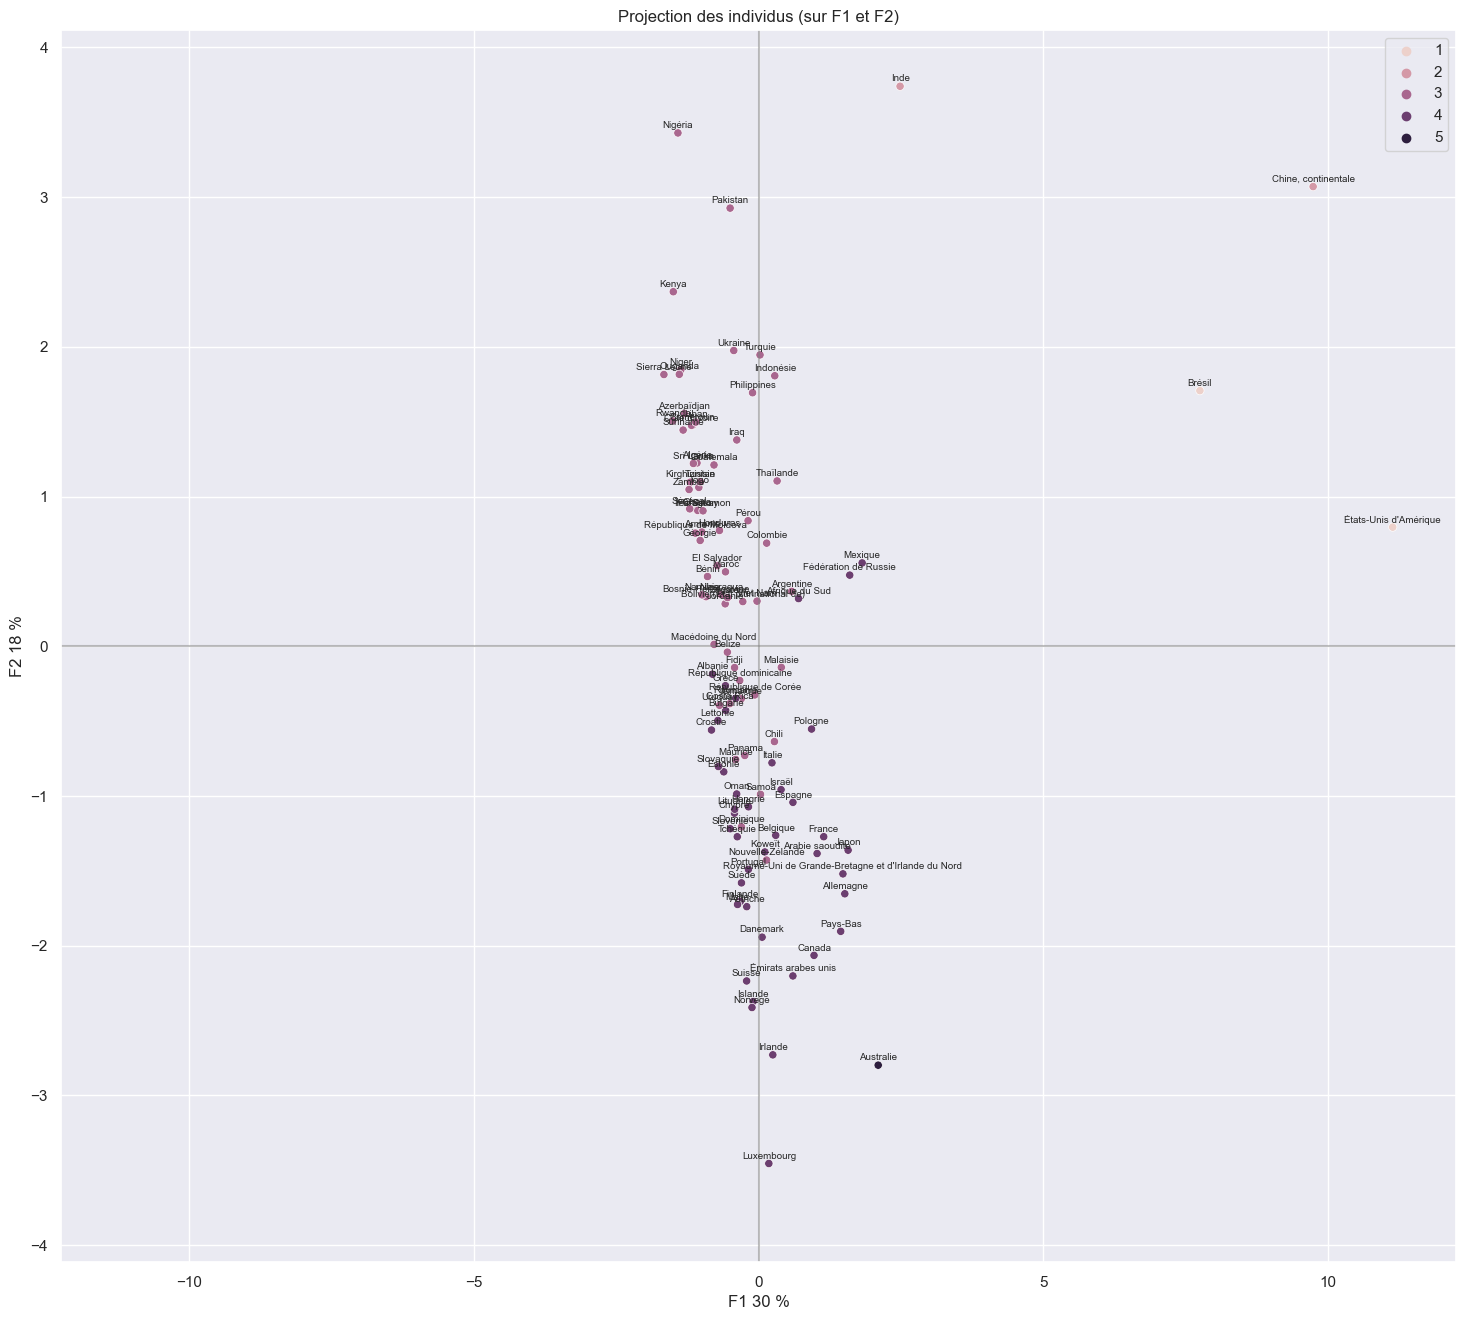

In [151]:
display_factorial_planes(X_proj, 
                        (0, 1), 
                        pca,
                        labels=names,
                        clusters=labels_cah,
                        figsize=(18,16))

Créons un graphique par groupe pour plus de lisibilité.

Cluster 1:

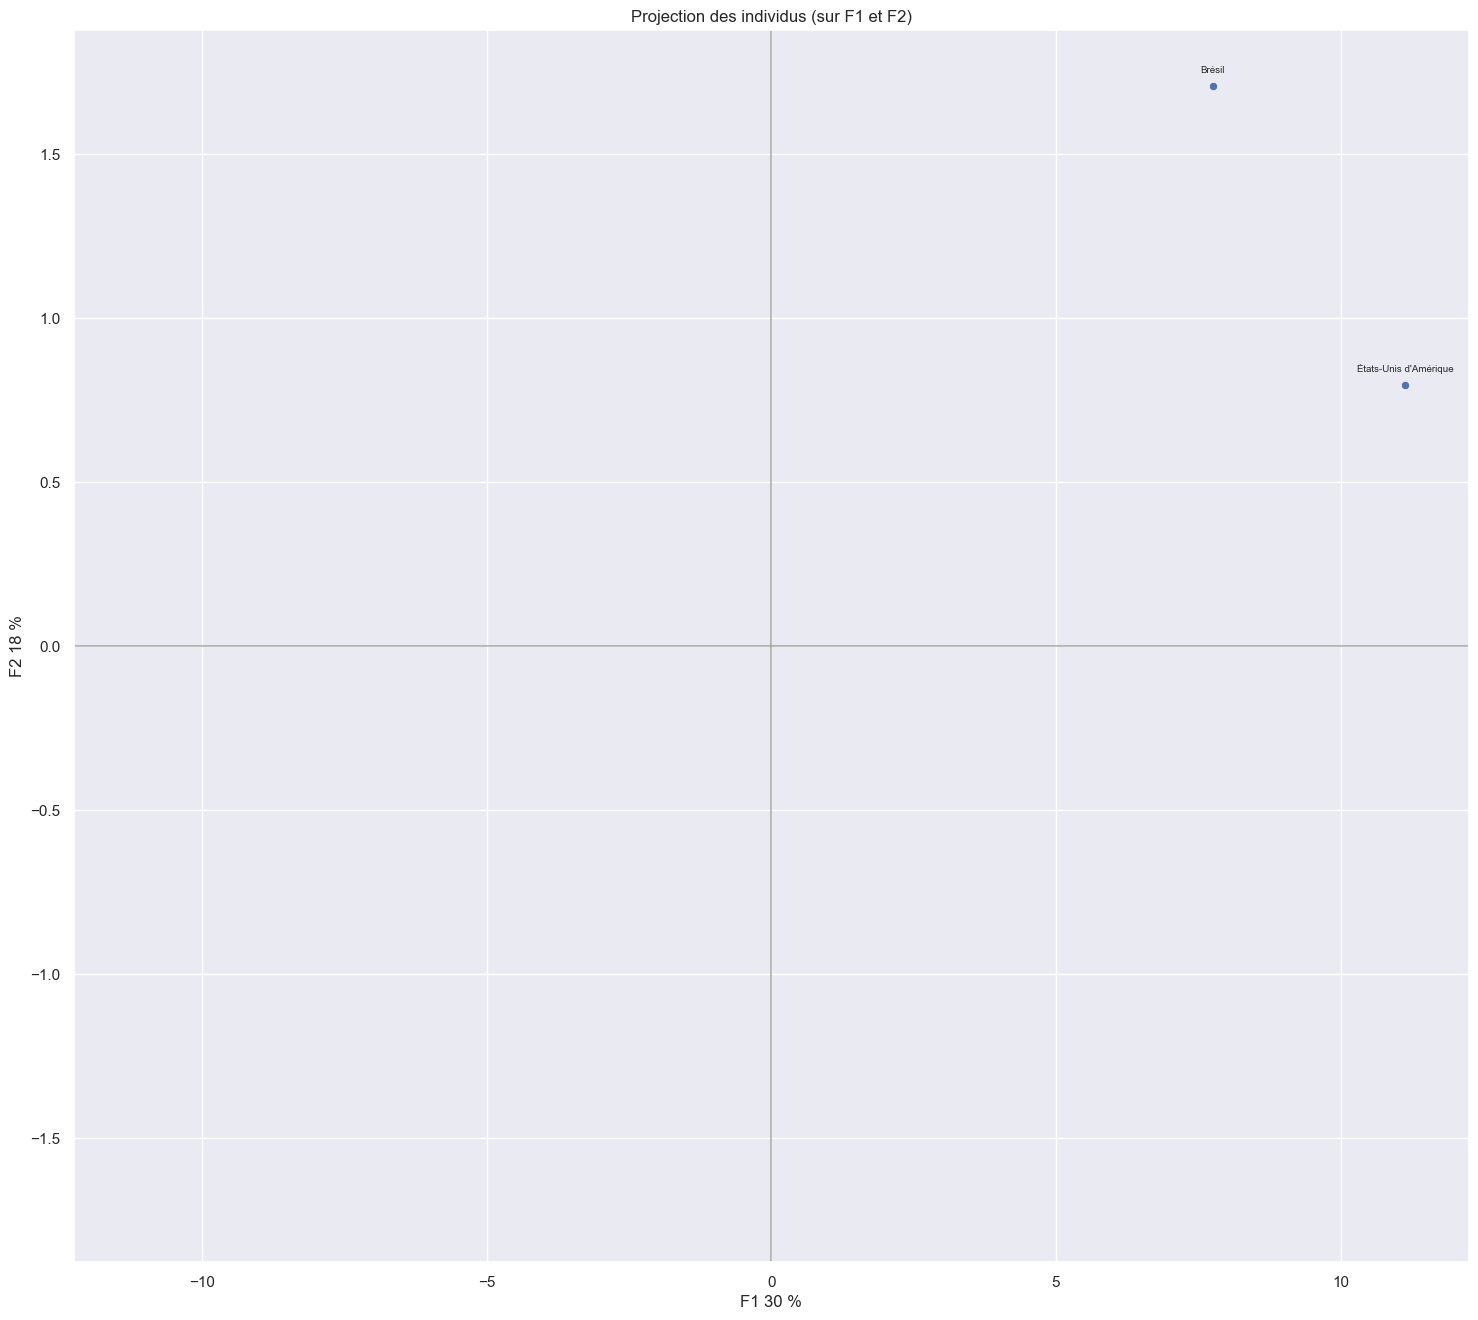

In [311]:
display_factorial_planes(X_proj[labels_cah == 1], 
                        (0, 1), 
                        pca,
                        labels=names[labels_cah == 1],
                        figsize=(18,16))

Cluster 2:

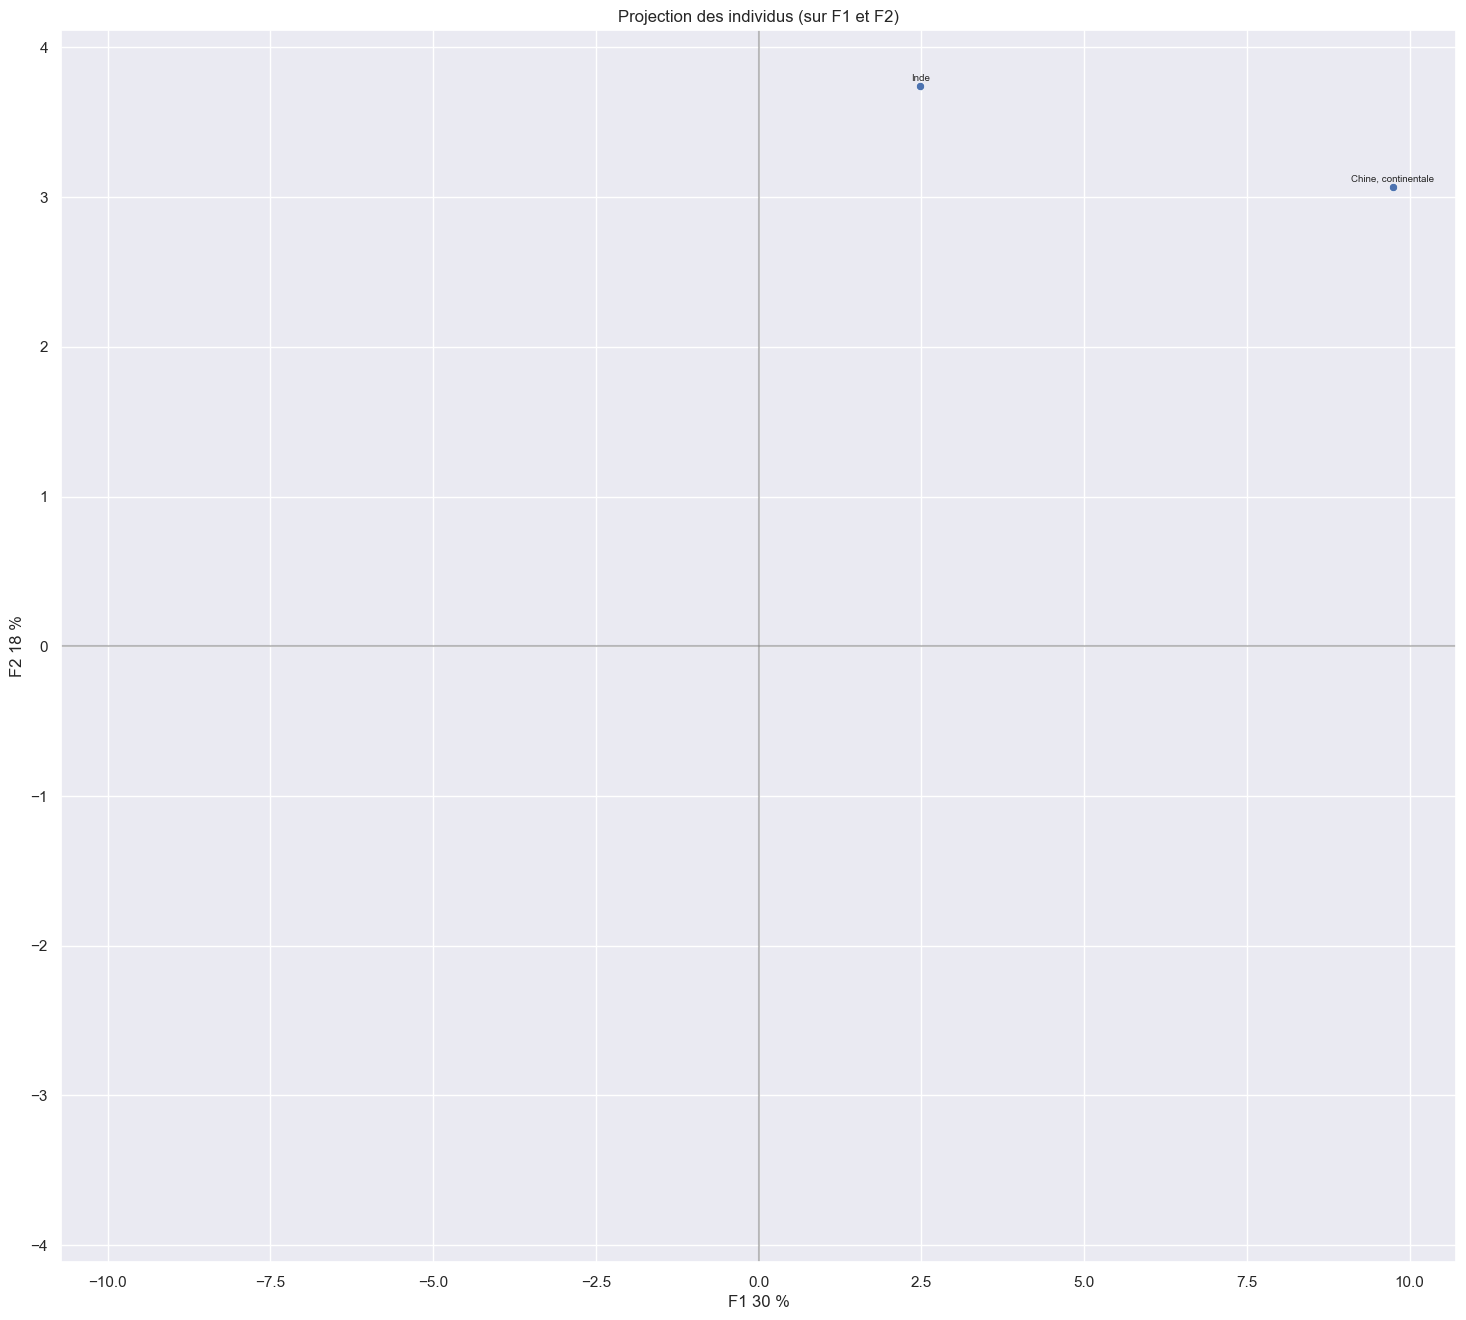

In [317]:
display_factorial_planes(X_proj[labels_cah == 2], 
                        (0, 1), 
                        pca,
                        labels=names[labels_cah == 2],
                        figsize=(18,16))

Cluster 3:

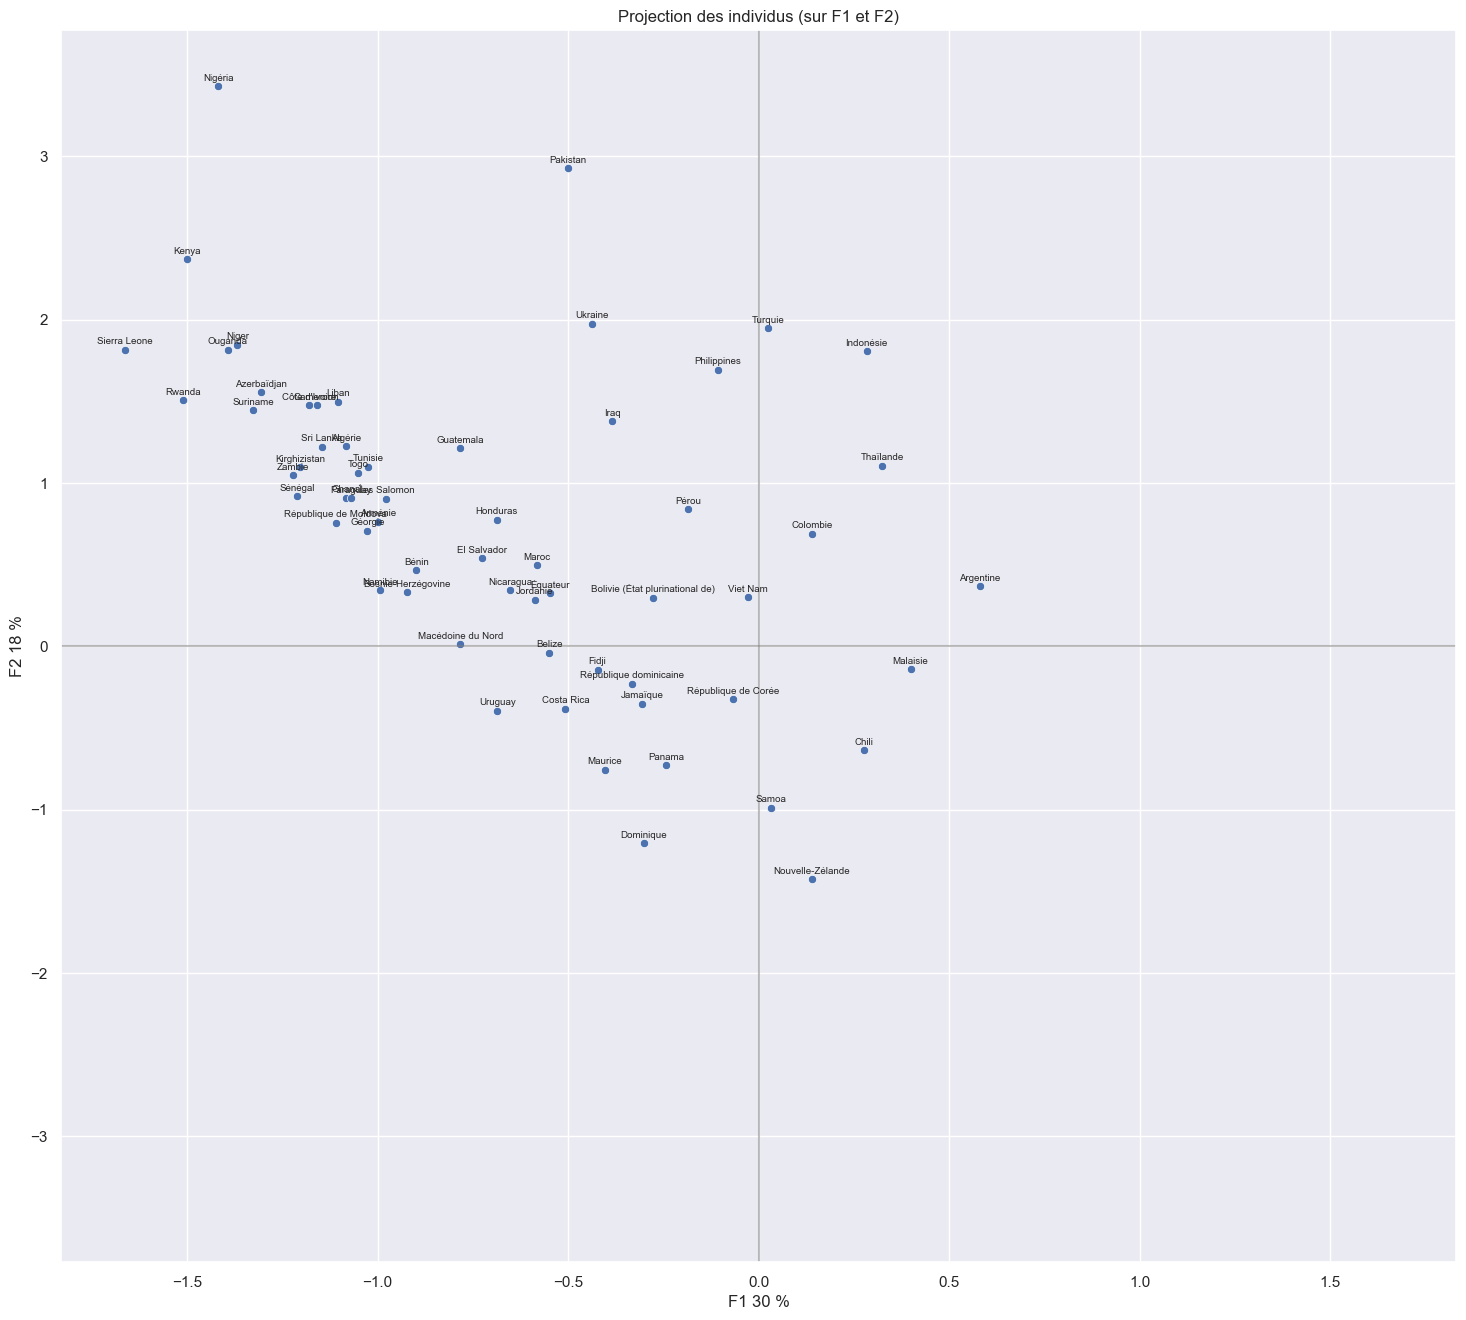

In [319]:
display_factorial_planes(X_proj[labels_cah == 3], 
                        (0, 1), 
                        pca,
                        labels=names[labels_cah == 3],
                        figsize=(18,16))

Cluster 4:

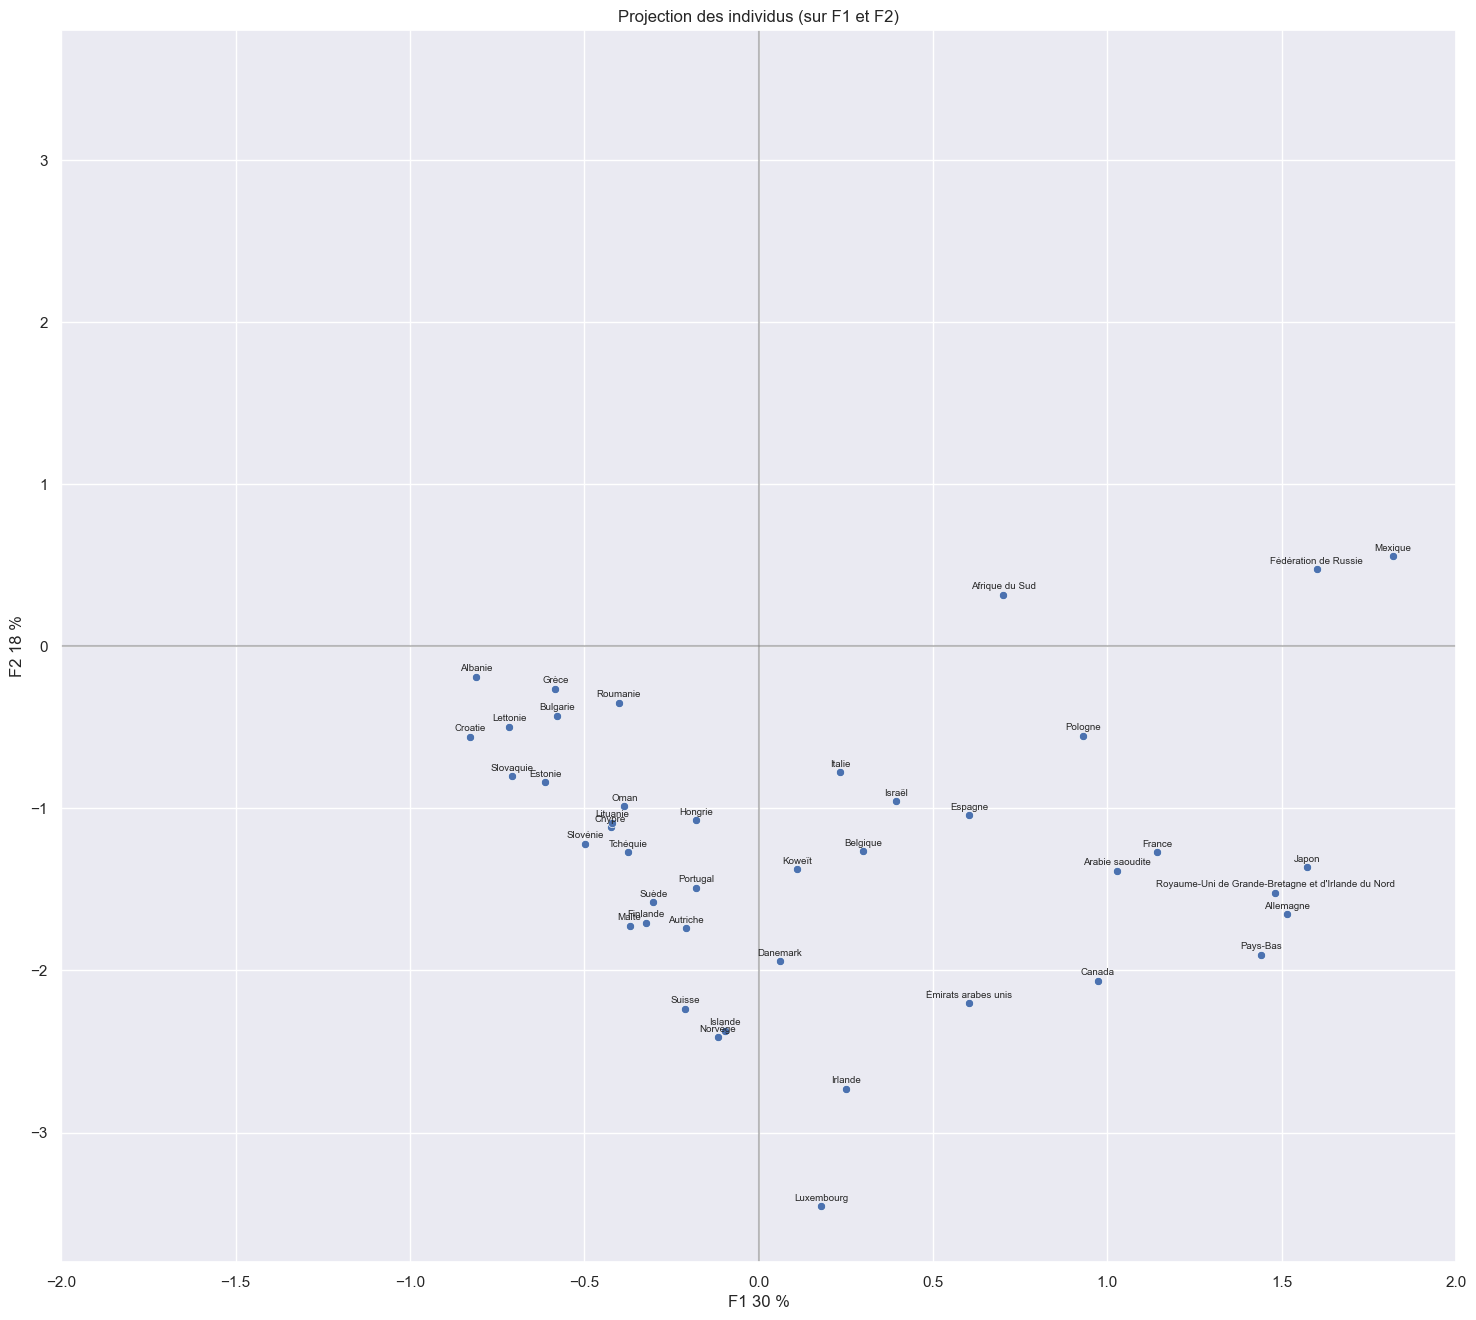

In [321]:
display_factorial_planes(X_proj[labels_cah == 4], 
                        (0, 1), 
                        pca,
                        labels=names[labels_cah == 4],
                        figsize=(18,16))

Cluster 5:

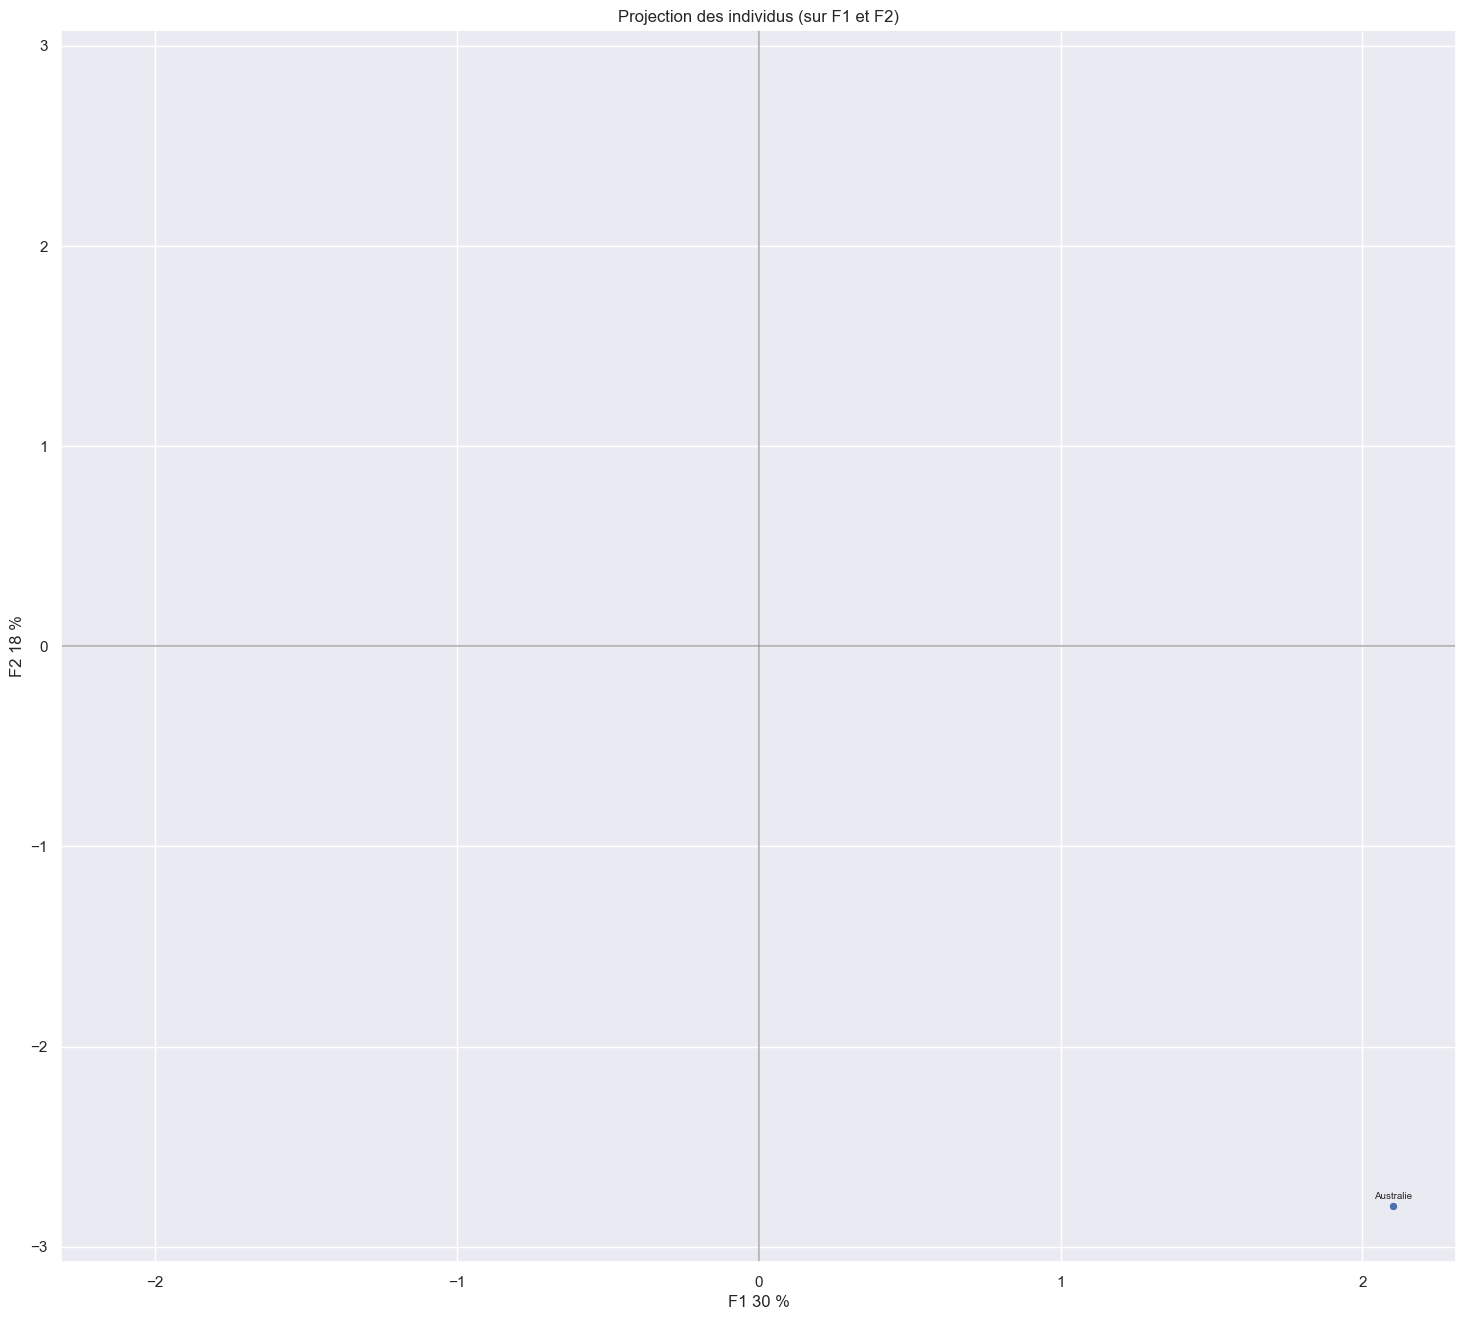

In [323]:
display_factorial_planes(X_proj[labels_cah == 5], 
                        (0, 1), 
                        pca,
                        labels=names[labels_cah == 5],
                        figsize=(18,16))

Un simple coup d'œil aux différents clusters nous permet déjà d'en éliminer quelques-uns. Les clusters 1, 2 et 5 ne contiennent en effet que 1 à 2 pays. Ce sont clairement des outliers.
Si on se base sur les observations que nous avons pu faire lors de notre ACP, le cluster le plus susceptible d'être une cible pour notre entreprise serait le 4. Ses éléments se trouvent en effet plutôt en bas au centre du premier plan factoriel. Les pays qui le composent semblent essentiellement se situer en Europe ou au Moyen-Orient.

## 5.2 K-means

### 5.2.1 Méthode du coude

C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

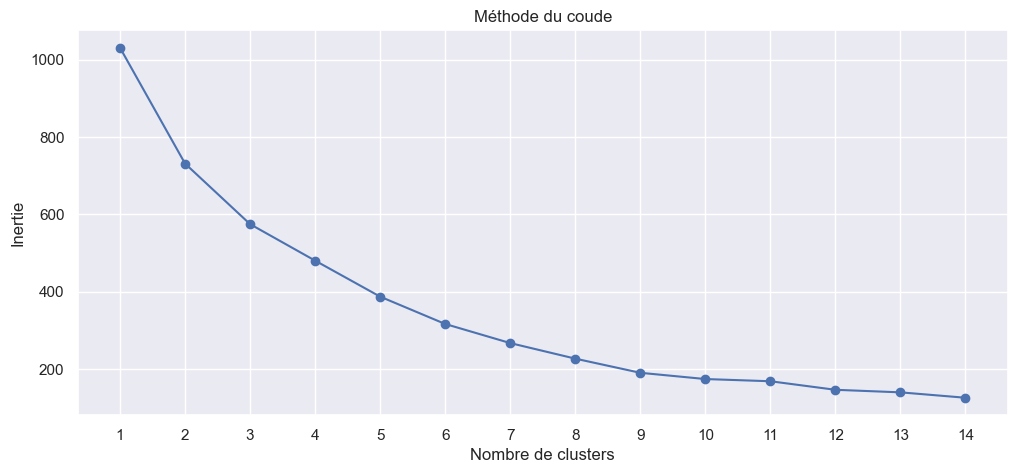

In [183]:
intertia_list = [ ]

k_list = range(1, 15)

for k in k_list : 
    
    kmeans = KMeans(n_clusters=k)
    
    kmeans.fit(X_proj)
    
    intertia_list.append(kmeans.inertia_)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

plt.plot(k_list, inertia_list, 'bo-')

plt.xticks(k_list)

plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Méthode du coude')

plt.show()

On peut observer une cassure dans la courbe autour de 5-6 clusters. Cette observation semble alignée avec celle effectuée sur le dendrogramme. Nous allons donc conserver une valeur de 5 pour K, le nombre de clusters.

### 5.2.2 K-means final

In [190]:
k_km_final = 5

kmeans = KMeans(n_clusters = k_km_final)

kmeans.fit(X_proj)

labels_km = kmeans.labels_
labels_km

C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 3, 2, 2, 0, 0, 4, 2, 3, 2, 0, 0, 0, 1, 2, 0, 0, 2, 0, 1, 2,
       0, 0, 2, 0, 2, 0, 0, 2, 2, 0, 2, 2, 2, 3, 2, 0, 3, 0, 2, 0, 0, 0,
       2, 2, 2, 2, 0, 2, 0, 3, 0, 2, 2, 3, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       3, 3, 2, 0, 2, 3, 3, 0, 0, 2, 0, 2, 2, 0, 2, 2, 3, 0, 3, 0, 0, 3,
       2, 2, 3, 2, 3, 2, 0, 2, 0, 0, 3, 3, 3, 0, 0, 0, 2, 0, 1, 0])

In [192]:
print('Répartition des 5 clusters (K-means):')
print(pd.Series(labels_km).value_counts().sort_index())

Répartition des 5 clusters (K-means):
0    47
1     3
2    39
3    18
4     1
Name: count, dtype: int64


In [194]:
centroids = kmeans.cluster_centers_
centroids

array([[-0.35452516,  0.42386347,  0.59704067, -0.19139497, -0.54418428,
         0.17395138],
       [ 9.544323  ,  1.85747491, -0.1224414 ,  1.27902545, -0.42251826,
        -0.77489403],
       [ 0.15138305, -1.35202826, -0.75345481, -0.01201194,  0.14452215,
        -0.08517627],
       [-1.10970568,  1.66849008, -0.32841929,  0.48431864,  0.92417634,
        -0.02622506],
       [ 2.10047659, -2.79772717,  7.6026976 , -3.09078237,  4.57267799,
        -2.05710724]])

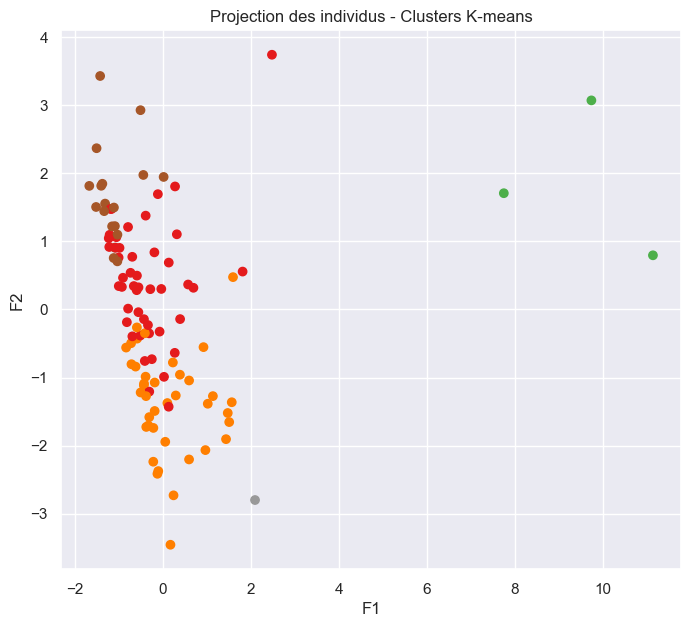

In [196]:
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

ax.scatter(X_proj[:, 0], X_proj[:, 1], c=labels_km, cmap="Set1")

ax.set_xlabel(f"F1")
ax.set_ylabel(f"F2")
ax.set_title("Projection des individus - Clusters K-means")

plt.show()

Visualisons les K-means sur le premier plan factoriel:

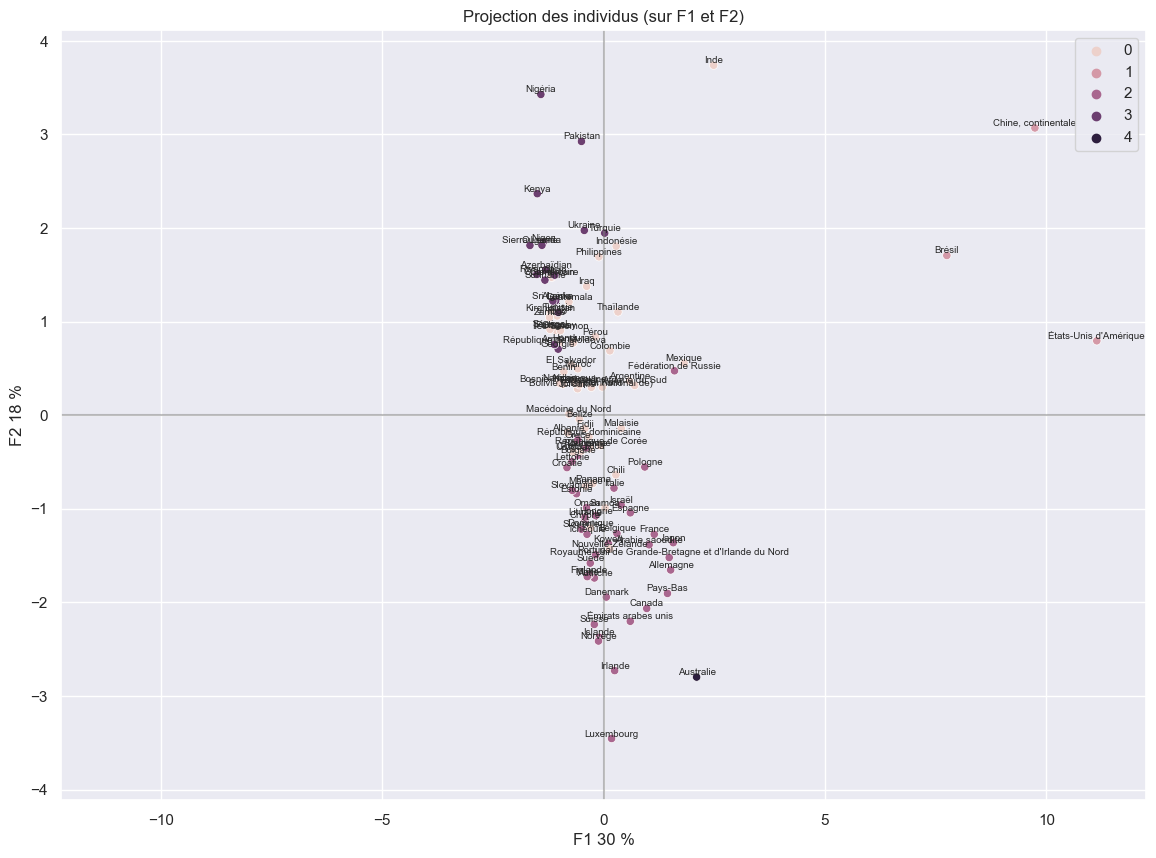

In [199]:
display_factorial_planes(X_proj, 
                         (0, 1), 
                         pca,
                         labels=names,
                         clusters=labels_km)

Regardons à présent chaque cluster plus en détail

In [202]:
df_copy['cluster_km'] = labels_km

In [204]:
print("Cluster 0:\n")

df_copy[df_copy['cluster_km'] == 0][['pays', 'continent']].sort_values('continent').head(50)

Cluster 0:



,pays,continent
0,Afrique du Sud,Afrique
94,Sénégal,Afrique
25,Côte d'Ivoire,Afrique
97,Togo,Afrique
16,Bénin,Afrique
61,Maroc,Afrique
17,Cameroun,Afrique
64,Namibie,Afrique
103,Zambie,Afrique
62,Maurice,Afrique


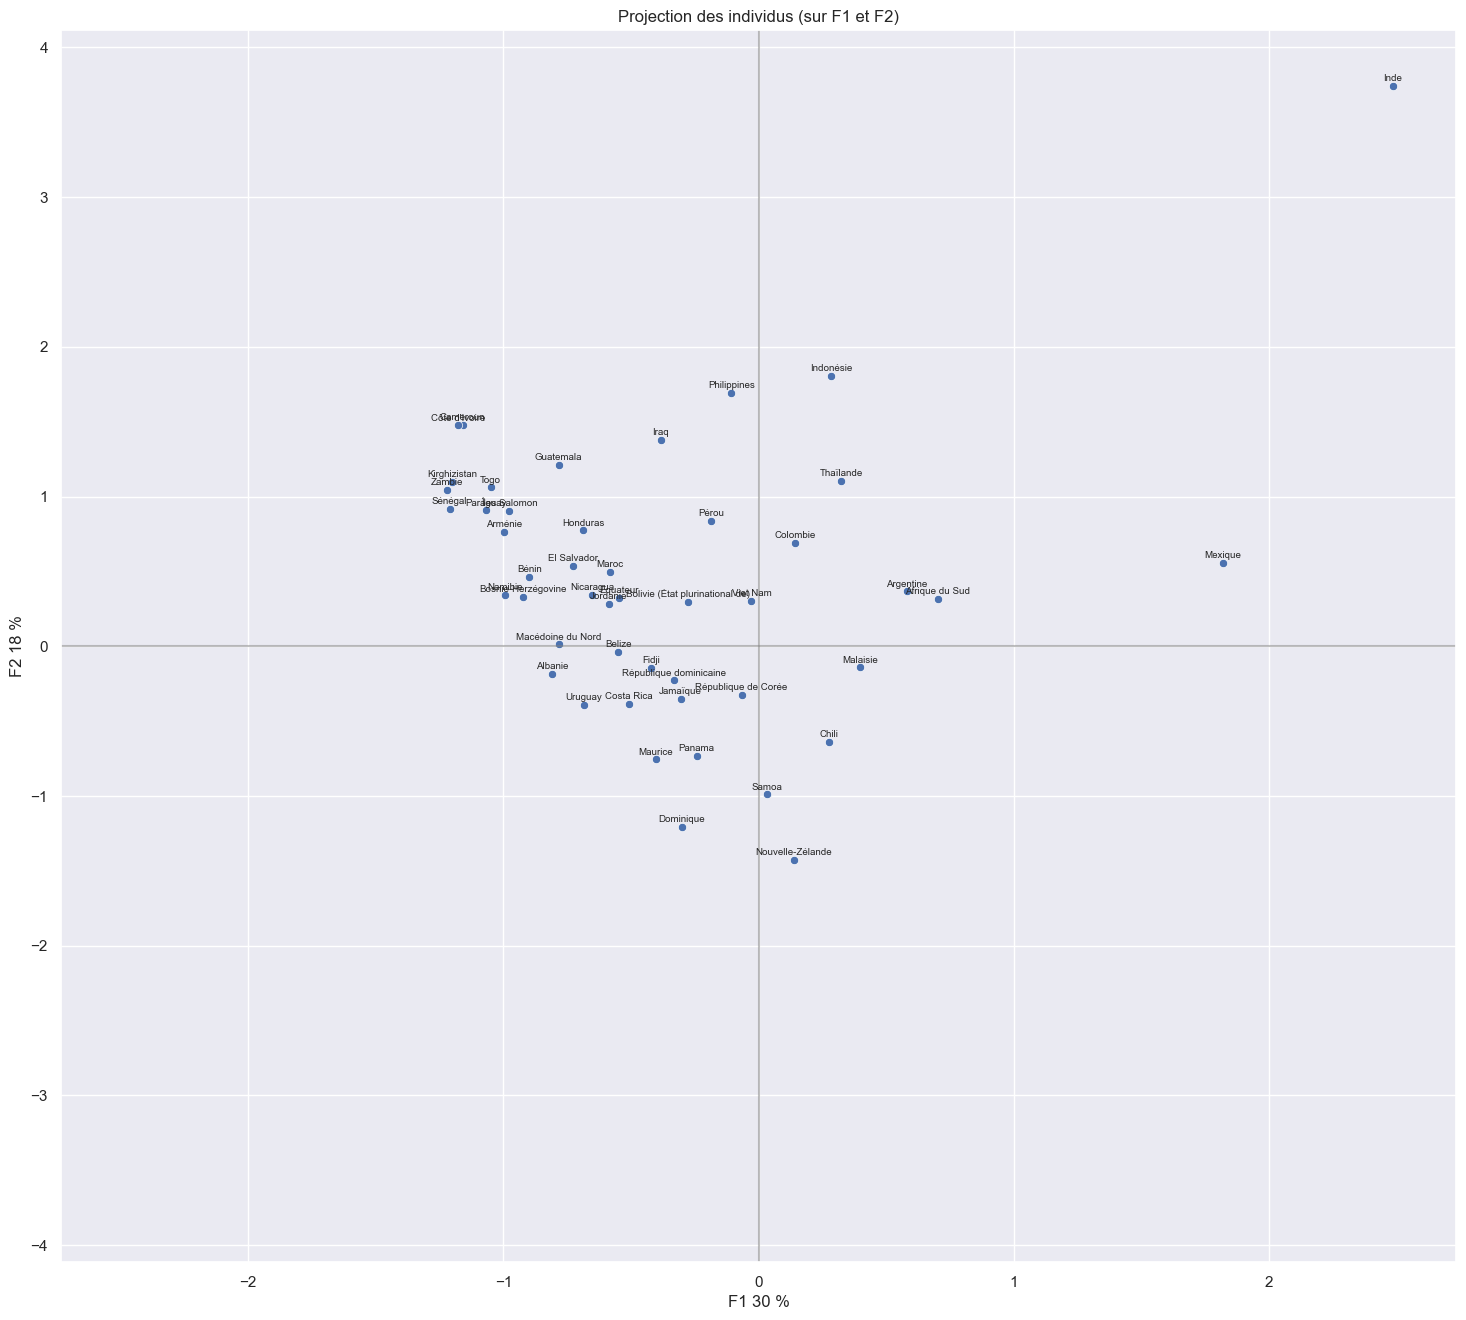

In [325]:
display_factorial_planes(X_proj[labels_km == 0], 
                        (0, 1), 
                        pca,
                        labels=names[labels_km == 0],
                        figsize=(18,16))

In [207]:
print("Cluster 1:\n")

df_copy[df_copy['cluster_km'] == 1][['pays', 'continent']].sort_values('continent').head(50)

Cluster 1:



,pays,continent
14,Brésil,Amérique
106,États-Unis d'Amérique,Amérique
20,"Chine, continentale",Asie


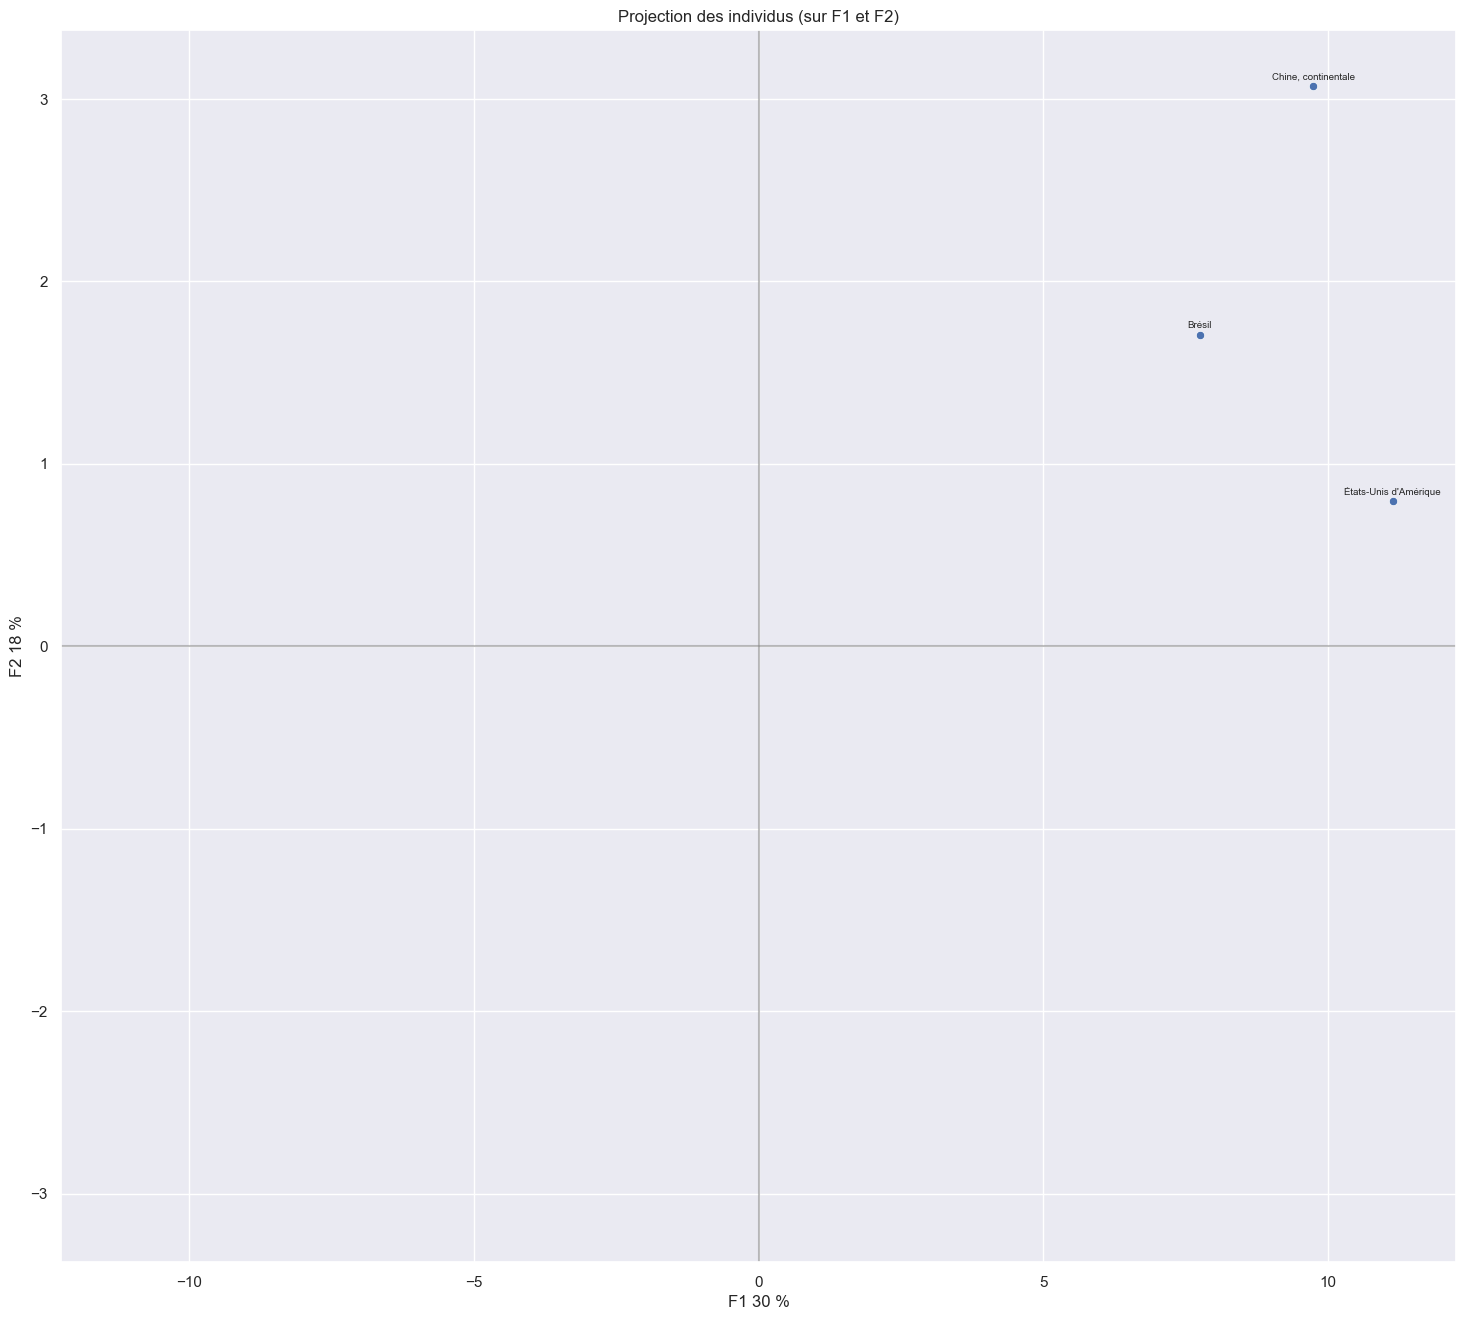

In [327]:
display_factorial_planes(X_proj[labels_km == 1], 
                        (0, 1), 
                        pca,
                        labels=names[labels_km == 1],
                        figsize=(18,16))

In [211]:
print("Cluster 2:\n")

df_copy[df_copy['cluster_km'] == 2][['pays', 'continent']].sort_values('continent').head(50)

Cluster 2:



,pays,continent
18,Canada,Amérique
104,Émirats arabes unis,Asie
46,Israël,Asie
34,Fédération de Russie,Asie
70,Oman,Asie
49,Japon,Asie
53,Koweït,Asie
4,Arabie saoudite,Asie
81,Royaume-Uni de Grande-Bretagne et d'Irlande du...,Europe
80,Roumanie,Europe


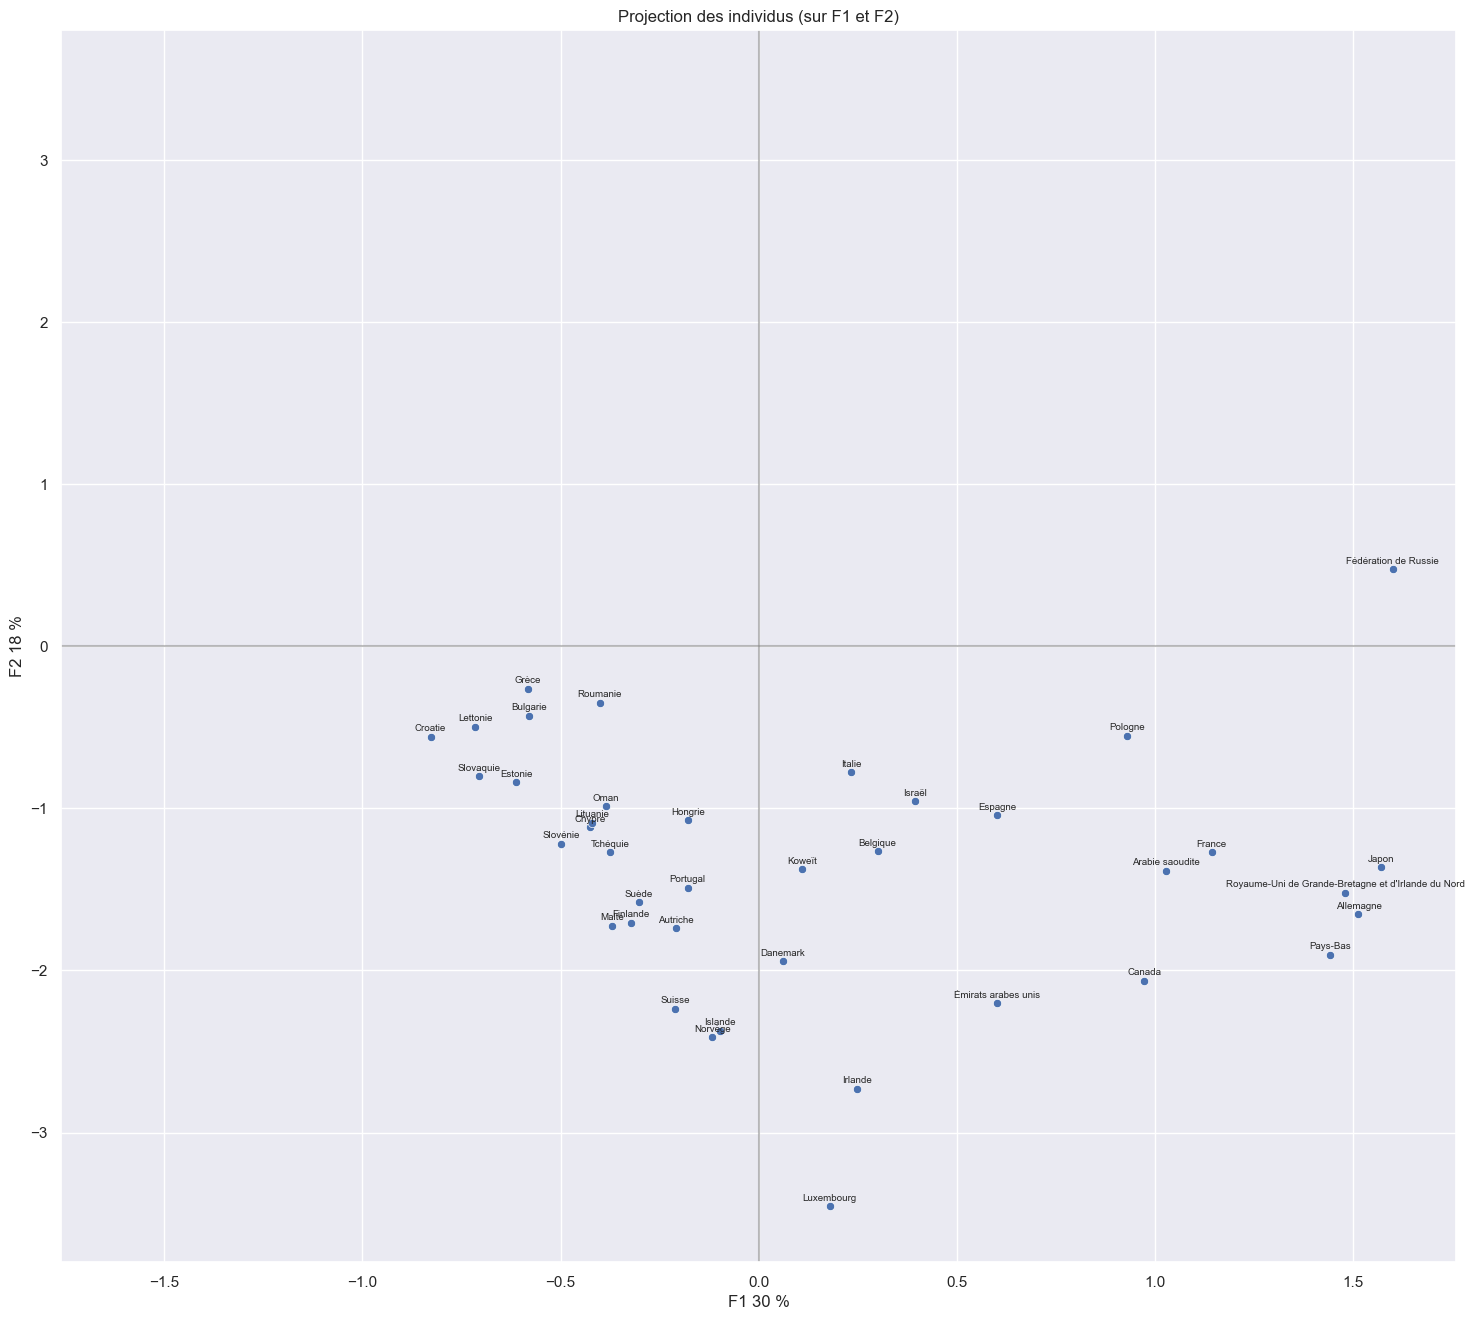

In [329]:
display_factorial_planes(X_proj[labels_km == 2], 
                        (0, 1), 
                        pca,
                        labels=names[labels_km == 2],
                        figsize=(18,16))

In [215]:
print("Cluster 3:\n")

df_copy[df_copy['cluster_km'] == 3][['pays', 'continent']].sort_values('continent').head(50)

Cluster 3:



,pays,continent
2,Algérie,Afrique
98,Tunisie,Afrique
87,Sierra Leone,Afrique
82,Rwanda,Afrique
67,Nigéria,Afrique
66,Niger,Afrique
71,Ouganda,Afrique
51,Kenya,Afrique
35,Ghana,Afrique
92,Suriname,Amérique


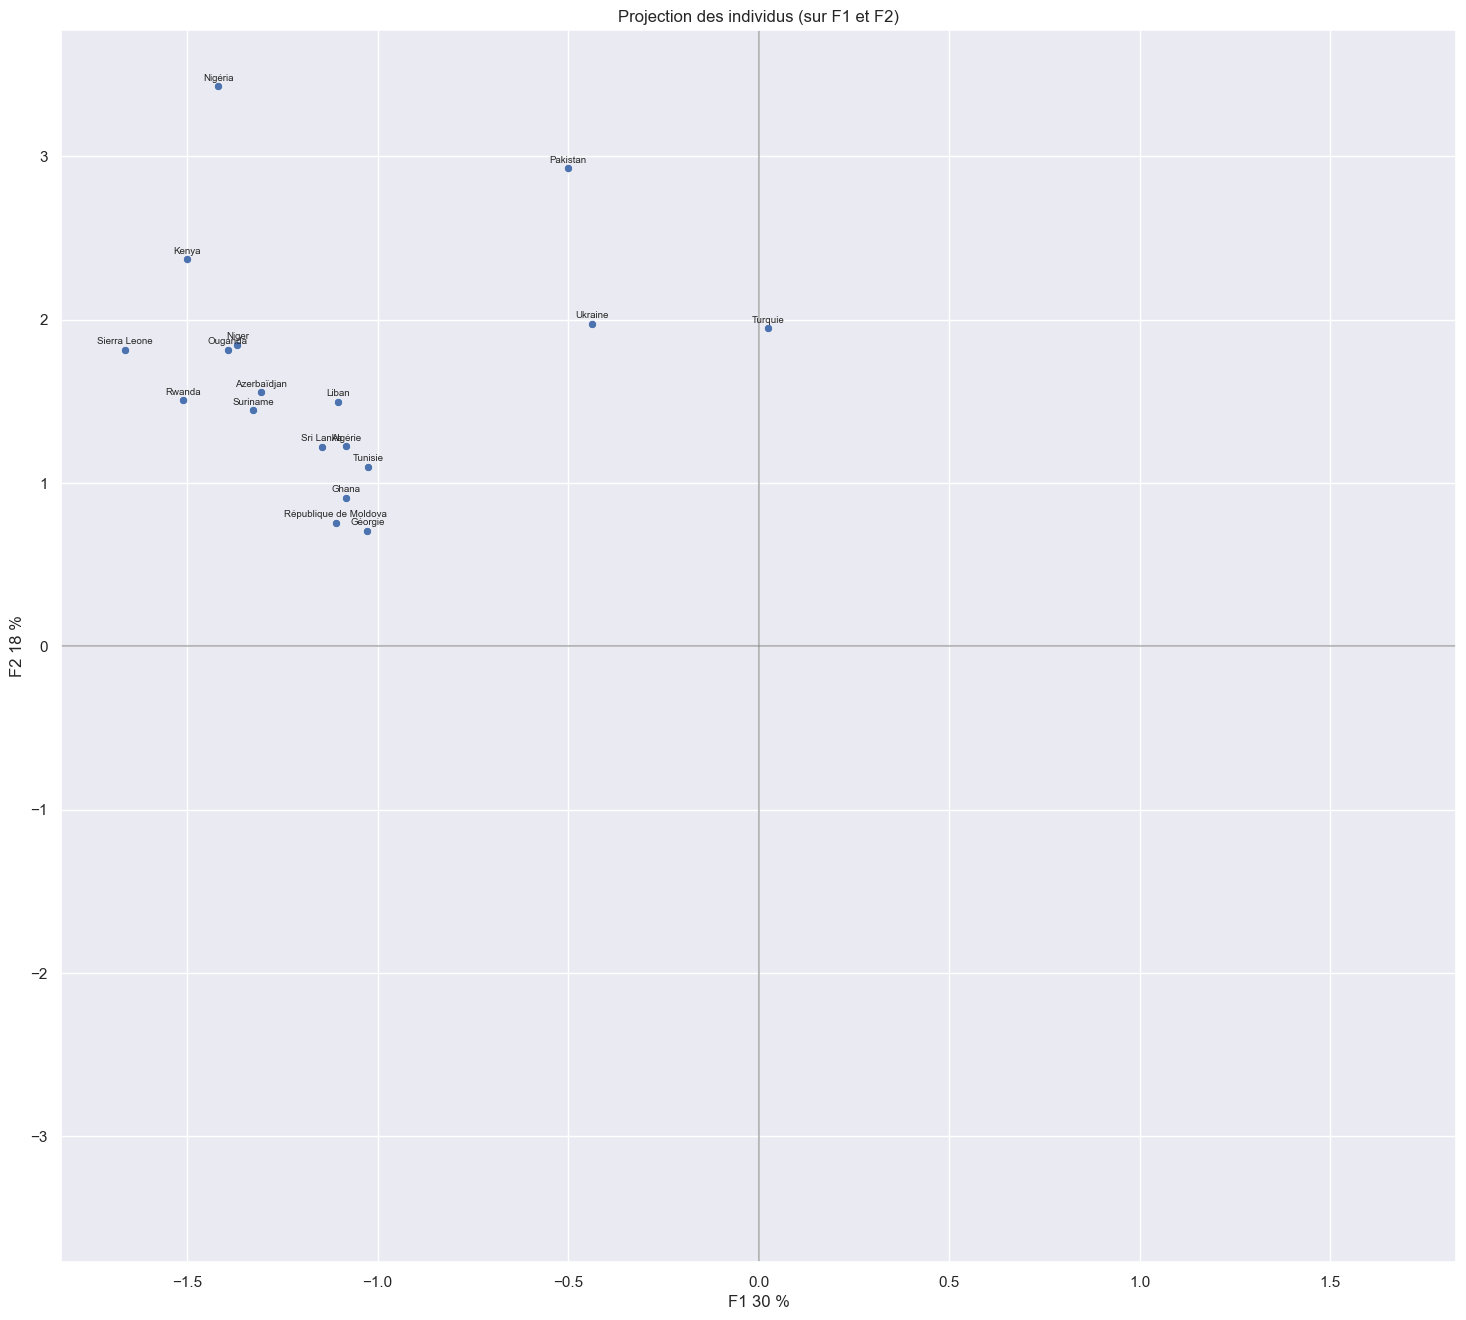

In [331]:
display_factorial_planes(X_proj[labels_km == 3], 
                        (0, 1), 
                        pca,
                        labels=names[labels_km == 3],
                        figsize=(18,16))

In [219]:
print("Cluster 4:\n")

df_copy[df_copy['cluster_km'] == 4][['pays', 'continent']].sort_values('continent').head(50)

Cluster 4:



,pays,continent
7,Australie,Océanie


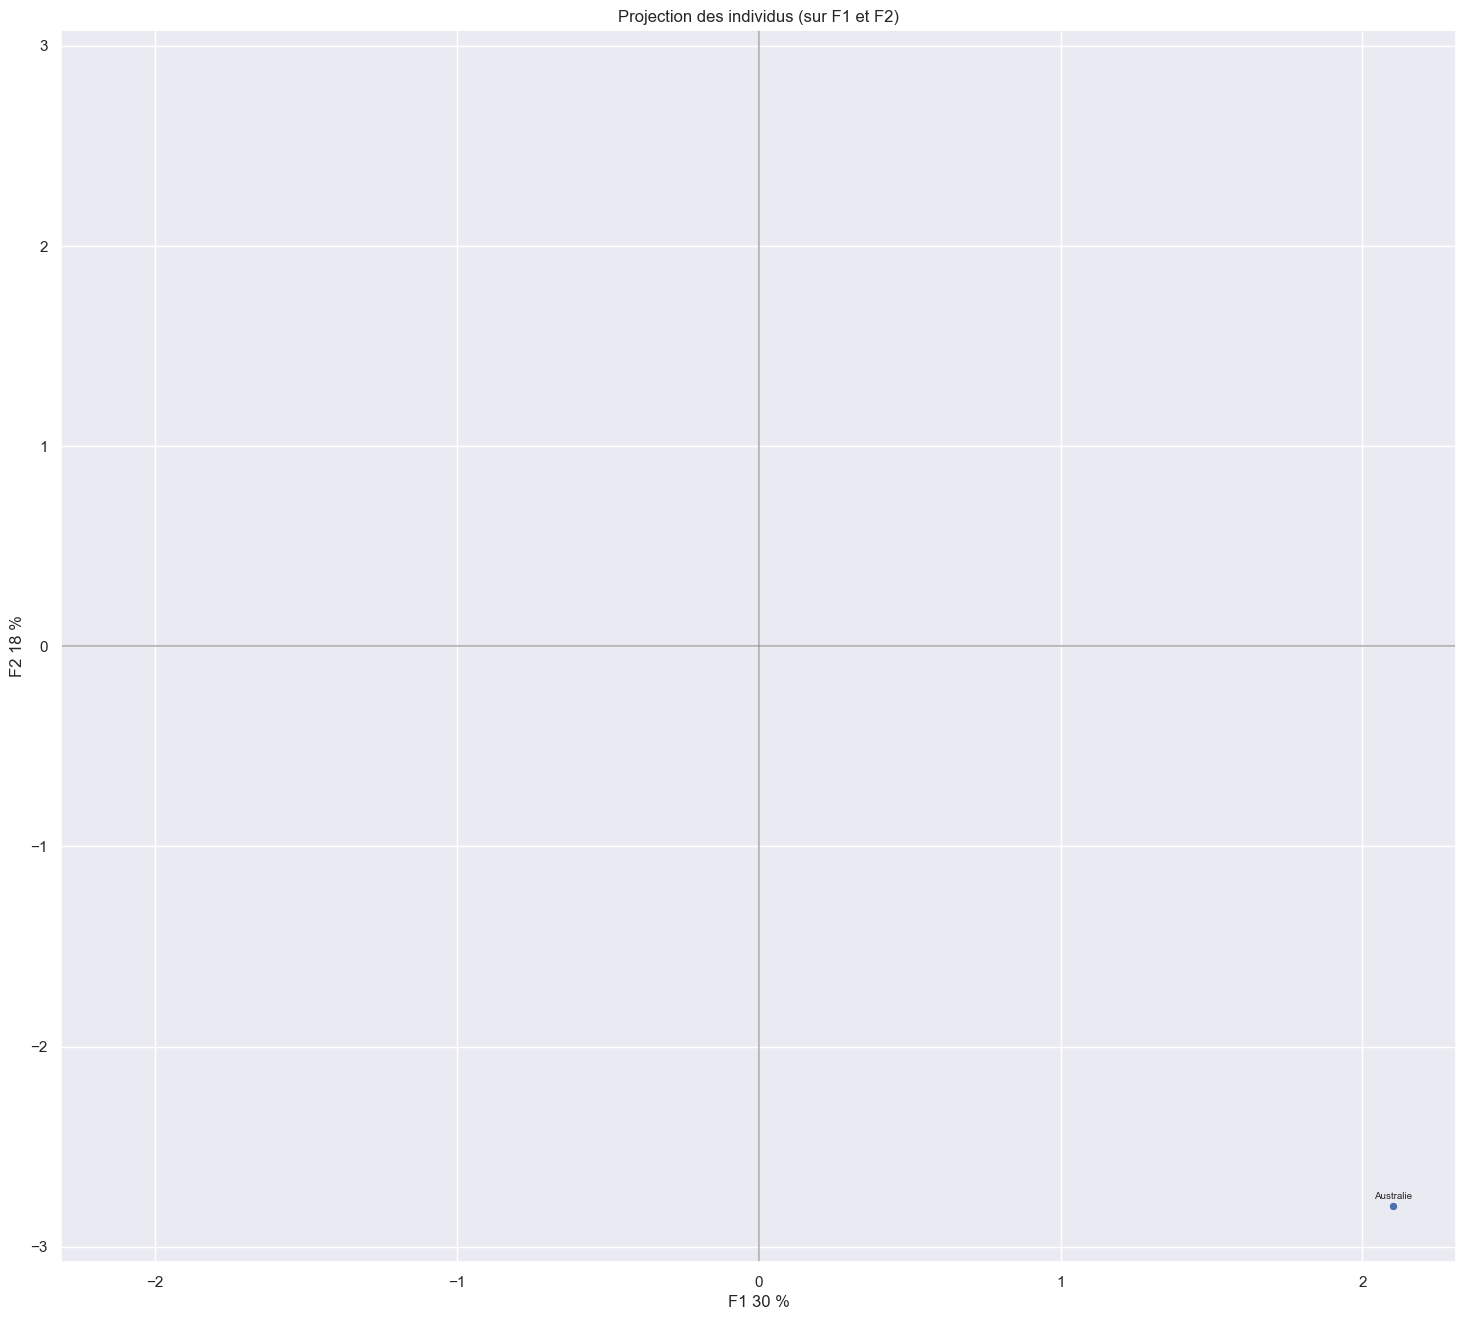

In [333]:
display_factorial_planes(X_proj[labels_km == 4], 
                        (0, 1), 
                        pca,
                        labels=names[labels_km == 4],
                        figsize=(18,16))

Comme avec la classification ascendante hiérarchique, la méthode du K-means met tout de suite en exergue des clusters d'outliers. Les clusters 1 et 4 ne contiennent là encore que quelques pays (respectivement 3 et 1). Ils ne constituent donc pas des profils "type" que l'on voudrait étudier plus avant pour en faire une cible de notre expansion internationale.
Là encore, en se basant sur les observations effectuées lors de notre ACP, le cluster le plus intéressant pour notre entreprise serait le 2. Il semble, comme le cluster 4 obtenu via la CAH, surtout composé de pays européen. 

### 5.2.3 Projection des centroïdes

In [225]:
centroids_proj = pd.DataFrame(centroids,
                              columns=["F1", "F2", "F3", "F4", "F5", "F6"],
                              index=["cluster_0", "cluster_1", "cluster_2", "cluster_3", "cluster_4"])

In [227]:
centroids_proj.round(2)

,F1,F2,F3,F4,F5,F6
cluster_0,-0.35,0.42,0.60,-0.19,-0.54,0.17
cluster_1,9.54,1.86,-0.12,1.28,-0.42,-0.77
cluster_2,0.15,-1.35,-0.75,-0.01,0.14,-0.09
cluster_3,-1.11,1.67,-0.33,0.48,0.92,-0.03
cluster_4,2.10,-2.80,7.60,-3.09,4.57,-2.06


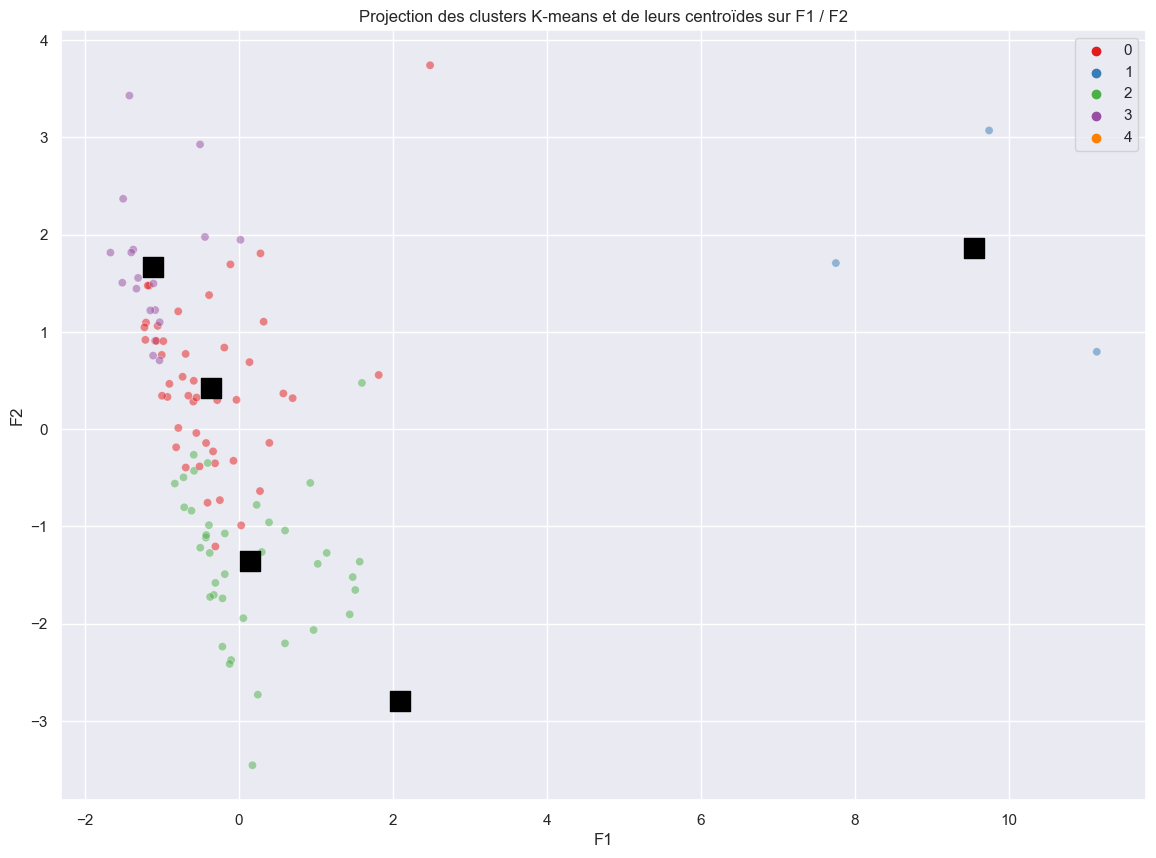

In [229]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

sns.scatterplot(x=X_proj[:, 0], y=X_proj[:, 1], hue=labels_km, palette="Set1", alpha=0.5, ax=ax)

ax.scatter(centroids_proj["F1"], centroids_proj["F2"], marker="s", c="black", s=200)

ax.set_title("Projection des clusters K-means et de leurs centroïdes sur F1 / F2")

ax.set_xlabel("F1")
ax.set_ylabel("F2")

plt.show()

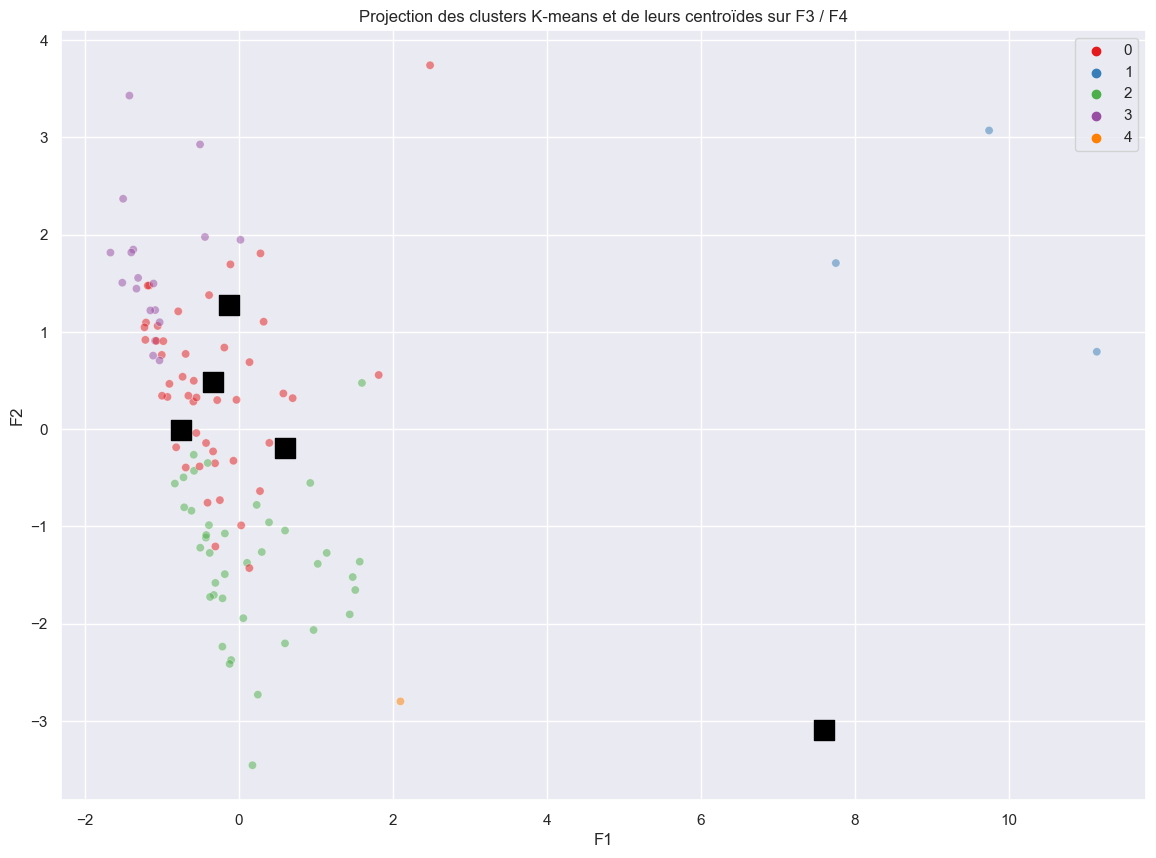

In [231]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

sns.scatterplot(x=X_proj[:, 0], y=X_proj[:, 1], hue=labels_km, palette="Set1", alpha=0.5, ax=ax)

ax.scatter(centroids_proj["F3"], centroids_proj["F4"], marker="s", c="black", s=200)

ax.set_title("Projection des clusters K-means et de leurs centroïdes sur F3 / F4")

ax.set_xlabel("F1")
ax.set_ylabel("F2")

plt.show()

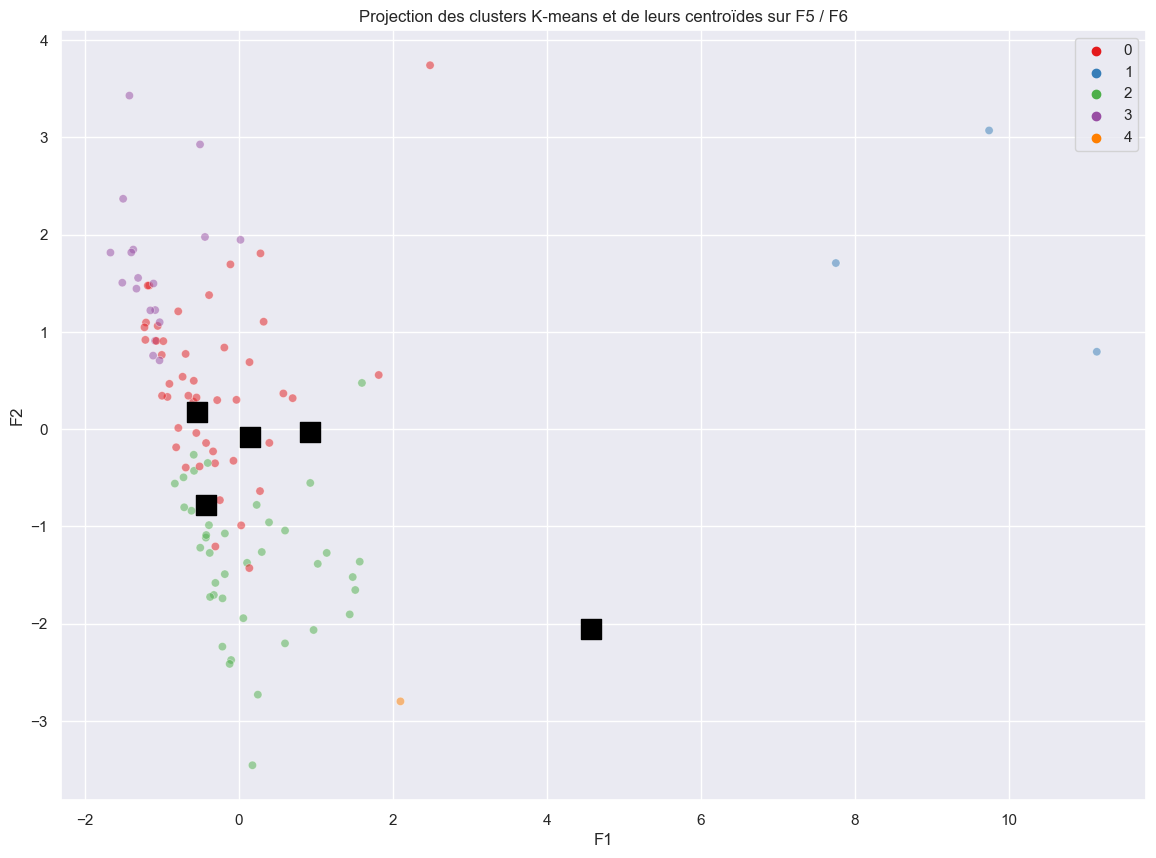

In [233]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

sns.scatterplot(x=X_proj[:, 0], y=X_proj[:, 1], hue=labels_km, palette="Set1", alpha=0.5, ax=ax)

ax.scatter(centroids_proj["F5"], centroids_proj["F6"], marker="s", c="black", s=200)

ax.set_title("Projection des clusters K-means et de leurs centroïdes sur F5 / F6")

ax.set_xlabel("F1")
ax.set_ylabel("F2")

plt.show()

### 5.2.4 Comparaison des différents clusters

In [236]:
df_result = df.copy()

df_result['cluster_cah'] = labels_cah
df_result['cluster_kmeans'] = labels_km

df_result.head()

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,continent,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire,cluster_cah,cluster_kmeans
0,Afrique du Sud,143.0,2118.0,63.0,514.0,1667.0,57009756,Afrique,-0.28,9353.5520,14591.0,41.38,6.90,4,0
1,Albanie,85.0,47.0,0.0,38.0,13.0,2884169,Europe,0.38,1603.5340,14155.0,0.55,3.91,4,0
2,Algérie,22.0,277.0,0.0,2.0,275.0,41389189,Afrique,-0.92,1340.3900,15428.0,0.77,5.04,3,3
3,Allemagne,71.0,1739.0,646.0,842.0,1514.0,82658409,Europe,0.59,439.8984,61992.0,1138.30,2.76,4,2
4,Arabie saoudite,151.0,1435.0,10.0,722.0,616.0,33101178,Asie,-0.58,4694.5000,57943.0,17.10,-0.82,4,2


Moyenne des différentes varaibles par clusters obtenu grace à la classification ascendante hiérarchique:

In [238]:
profil_clusters_cah = df_result.groupby('cluster_cah')[features].mean().round(2)
profil_clusters_cah

,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
cluster_cah,,,,,,,,,,,
1,211.50,14124.00,3957.50,63.00,18057.50,2.664593e+08,-0.04,7623.28,41940.50,1584.15,0.38
2,33.00,10911.00,290.00,226.00,10890.50,1.379849e+09,-0.50,7409.73,39205.00,2403.12,0.26
3,66.30,407.77,32.52,42.87,408.49,3.035851e+07,-0.31,7235.17,13925.69,148.77,4.83
4,93.38,724.36,153.38,218.67,696.86,2.568477e+07,0.57,2380.16,49552.93,366.54,2.07
5,192.00,1171.00,42.00,16.00,1269.00,2.458462e+07,0.89,16975.46,56685.00,35645.04,0.89


Moyenne des différentes varaibles par clusters obtenu grace à la méthode K-means:

In [240]:
profil_clusters_km = df_result.groupby('cluster_kmeans')[features].mean().round(2)
profil_clusters_km

,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
cluster_kmeans,,,,,,,,,,,
0,80.53,624.51,28.38,79.11,582.09,5.510634e+07,-0.09,8295.70,14942.30,202.84,2.29
1,160.67,15469.67,2830.33,192.67,18117.00,6.513135e+08,-0.10,7823.93,51654.67,2064.85,-0.19
2,91.56,616.38,163.33,196.41,624.08,2.292536e+07,0.63,2046.23,52069.21,376.38,1.77
3,34.28,309.28,40.33,23.39,335.22,4.362327e+07,-0.88,4344.76,11390.56,113.21,11.47
4,192.00,1171.00,42.00,16.00,1269.00,2.458462e+07,0.89,16975.46,56685.00,35645.04,0.89


On va à présent standartiser les différents clusters obtenus via nos deux méthodes, pour pouvoir les visualiser dans une heatmap.

Heatmap CAH:

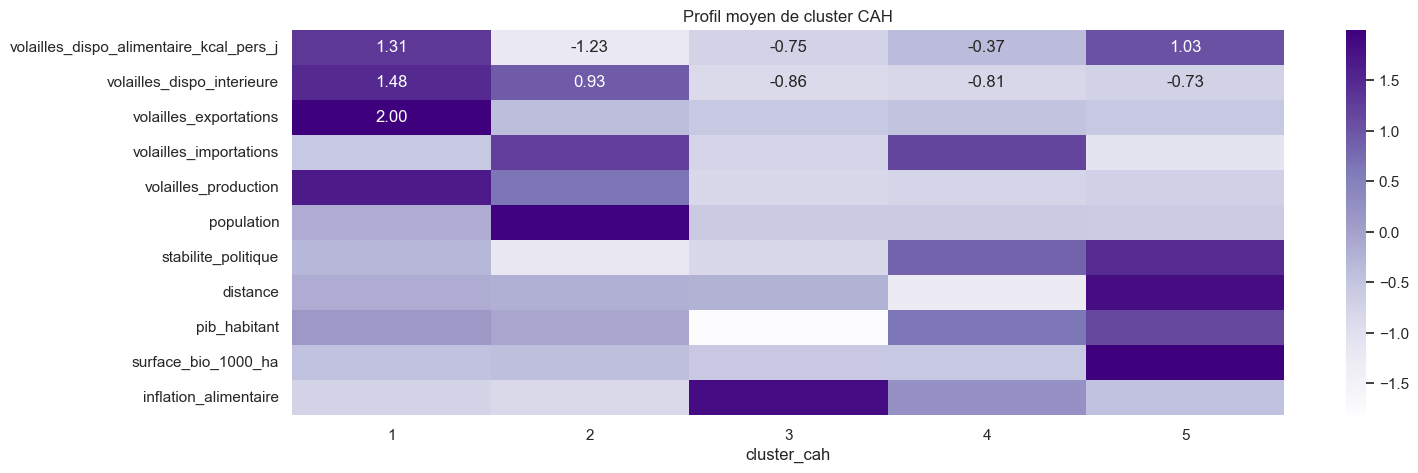

In [268]:
profil_scaled_cah = pd.DataFrame(
    scaler.fit_transform(profil_clusters_cah),
    columns=features,
    index=profil_clusters_cah.index
)

fig, ax = plt.subplots(1,1, figsize=(16, 5))
sns.heatmap(profil_scaled_cah.T, annot=True, fmt='.2f', cmap='Purples', ax=ax)


plt.title('Profil des cluster CAH')

plt.show()

La lecture de cette heatmap nous confirme que le cluster 4 obtenu via la CAH rassemble des pays ayant un profil intéressant pour le développement de notre entreprise. Ce sont des pays importateurs de volailles, stables politiquement, avec un pib par habitant élevé et situés à faible distance de la France.

Heatmap K-means:

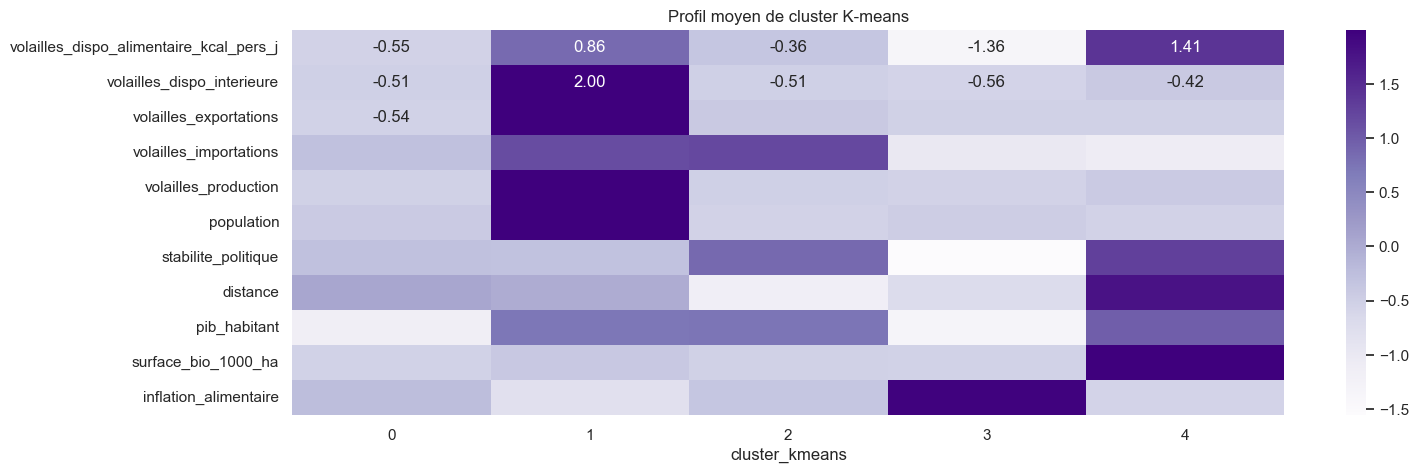

In [270]:
profil_scaled_km = pd.DataFrame(
    scaler.fit_transform(profil_clusters_km),
    columns=features,
    index=profil_clusters_km.index
)

fig, ax = plt.subplots(1,1, figsize=(16, 5))
sns.heatmap(profil_scaled_km.T, annot=True, fmt='.2f', cmap='Purples', ax=ax)

plt.title('Profil des cluster K-means')

plt.show()

Là encore, nos observations précédentes nous sont confirmées. Les pays du cluster 2, obtenu via la méthode du k-means, semblent les plus intéressants pour le développement de notre entreprise. Ce sont en effet de grands importateurs de volailles, sont stables politiquement, se situent proche de la France, et disposent d'un pib par habitant élevé.

Illustrons à présent la distribution de nos différents clusters au sein des différentes variables dans des boxplots:

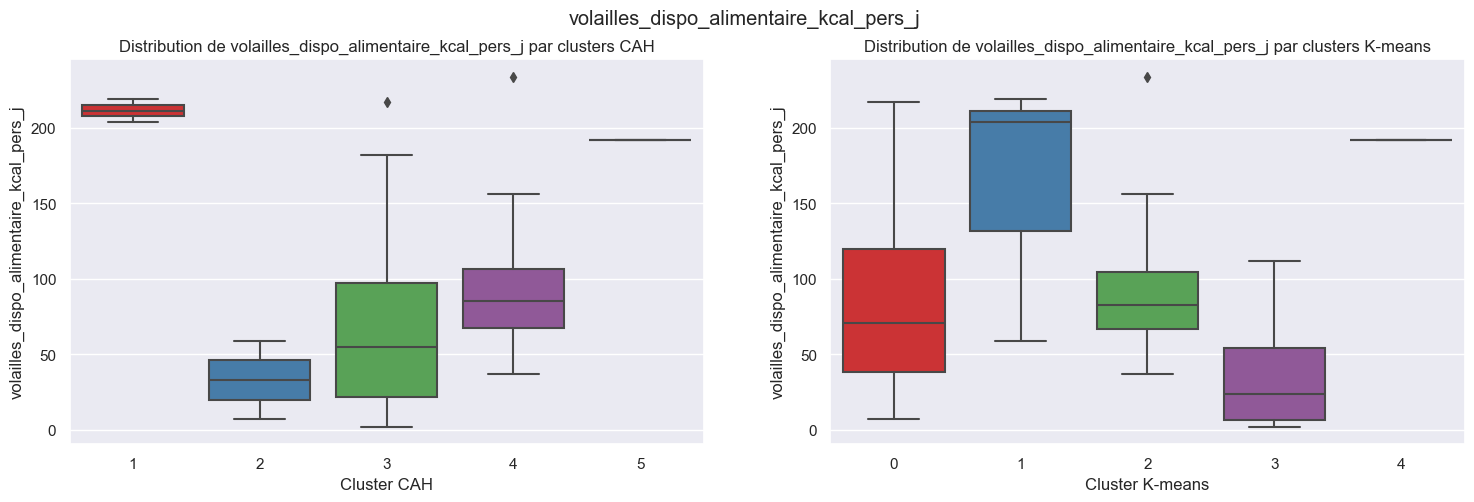

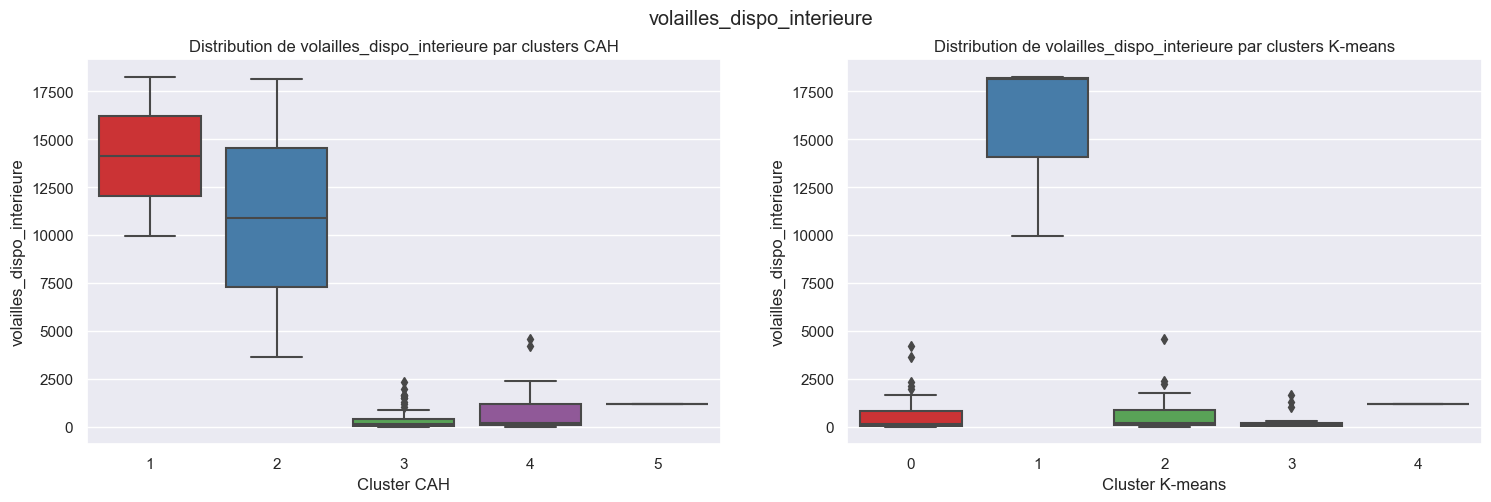

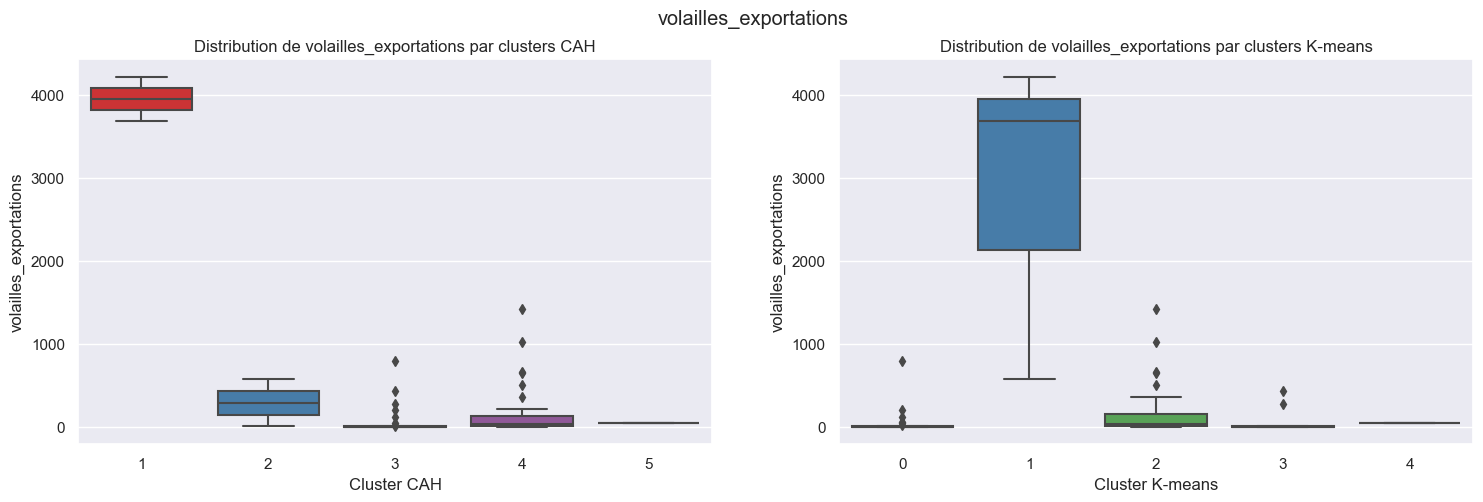

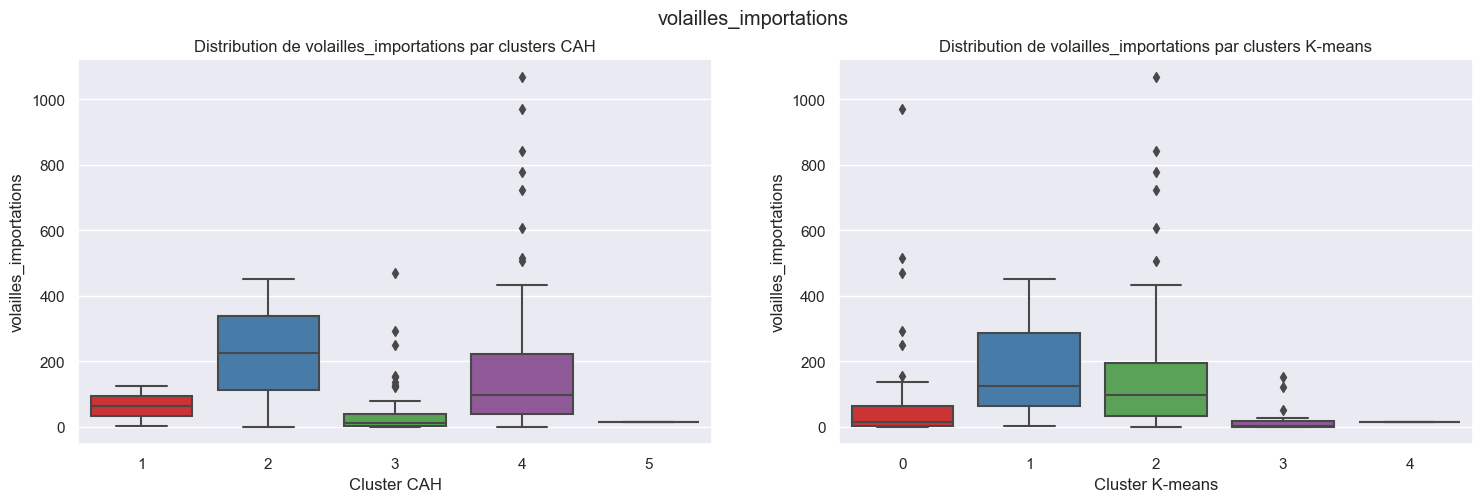

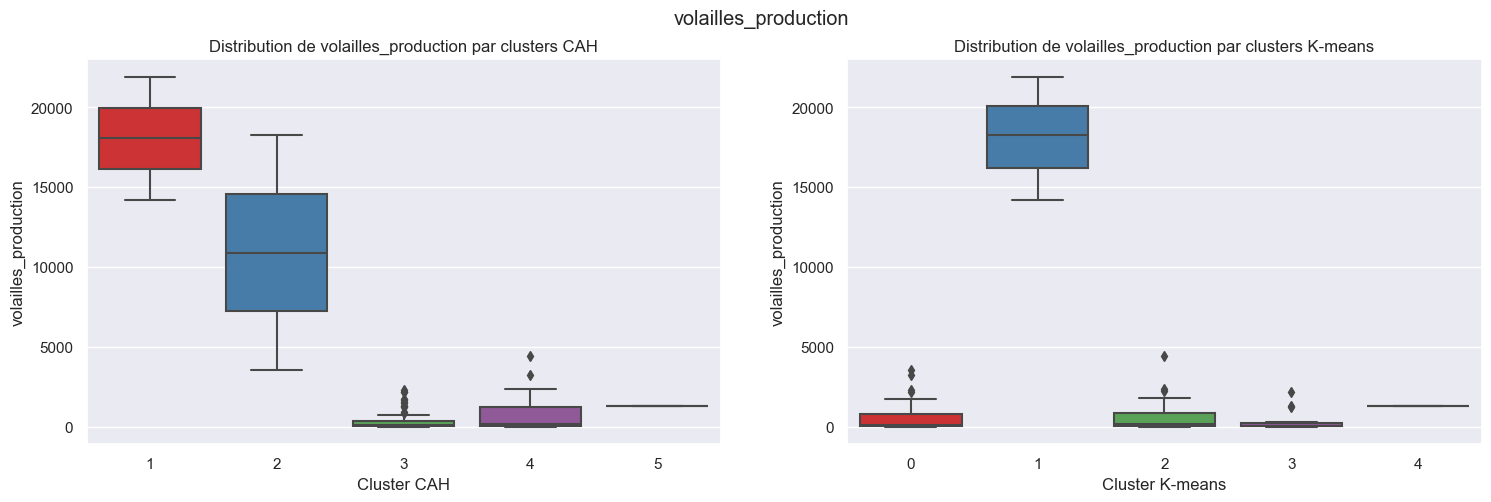

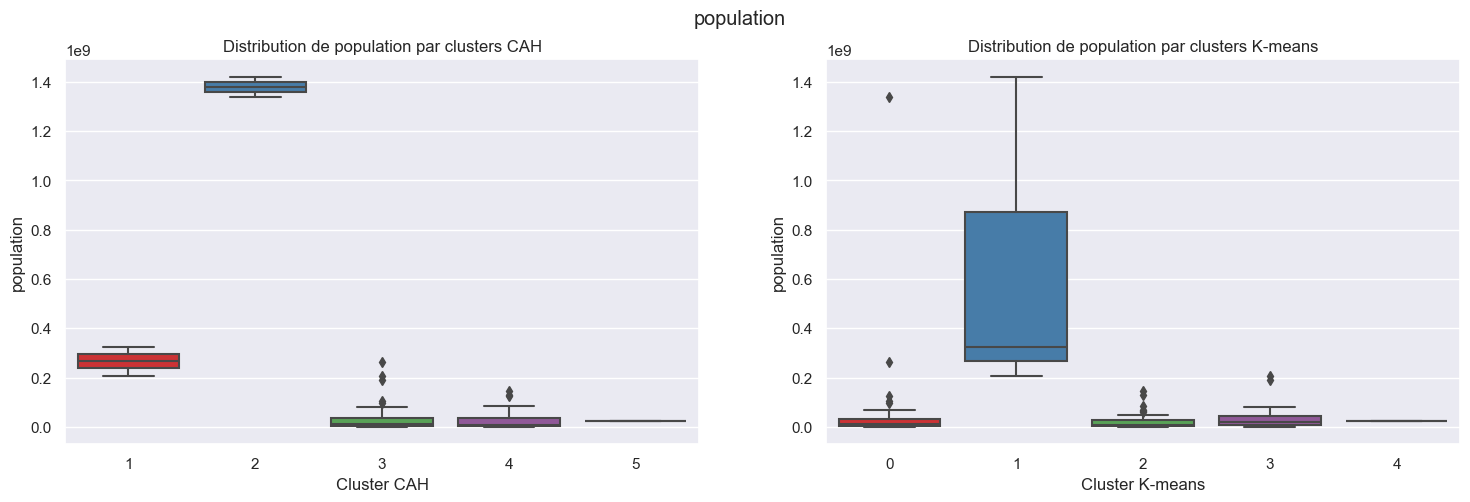

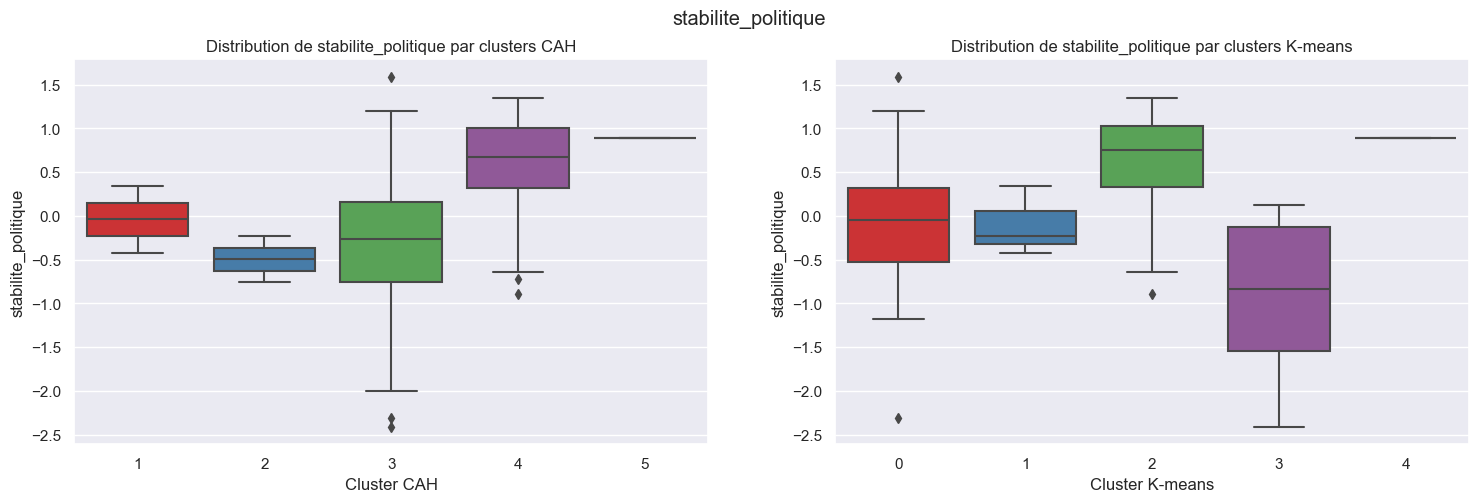

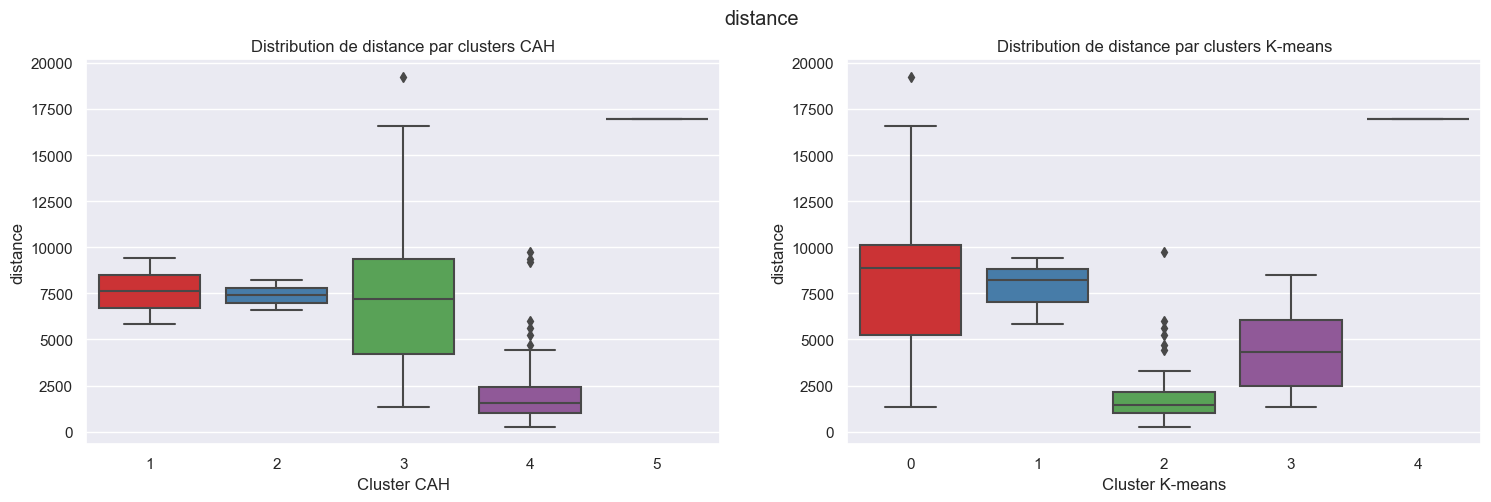

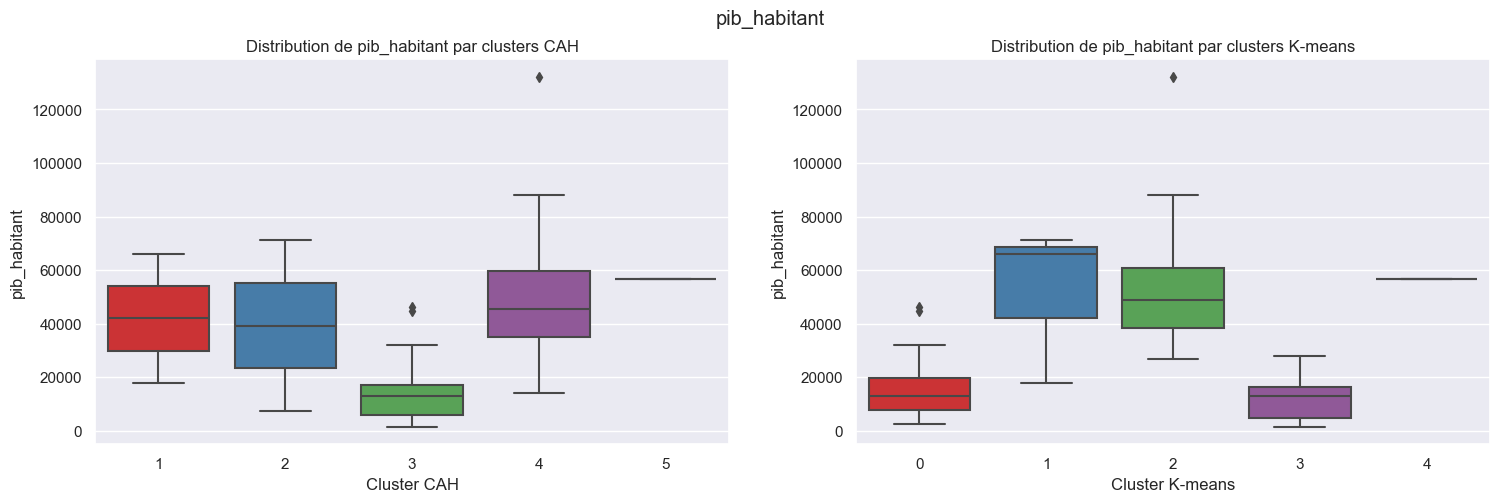

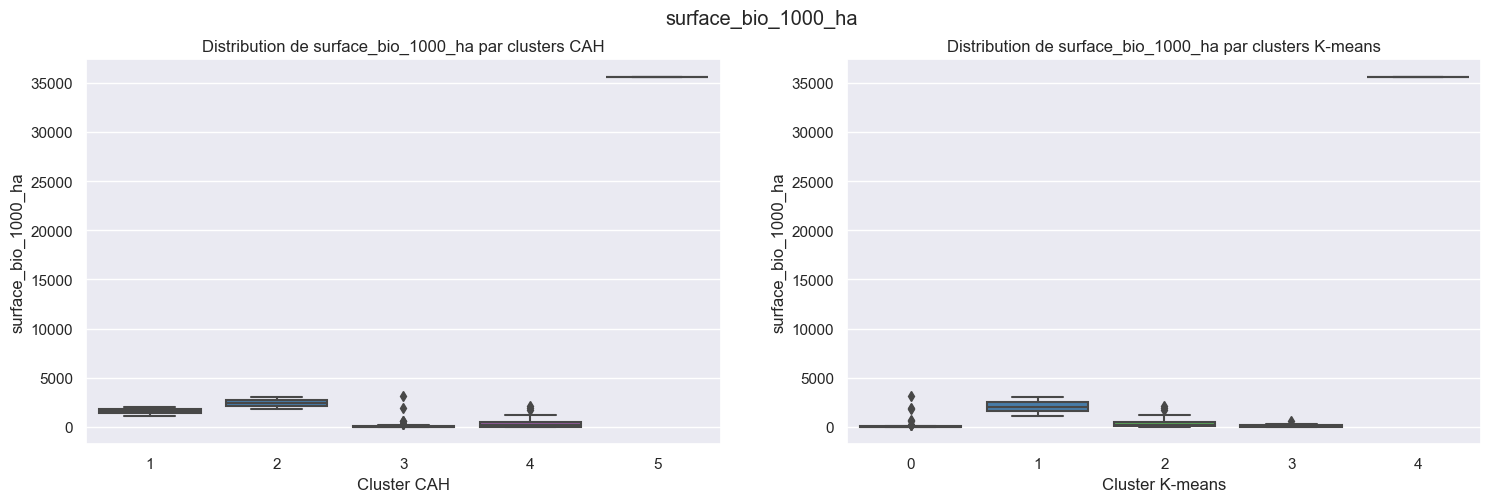

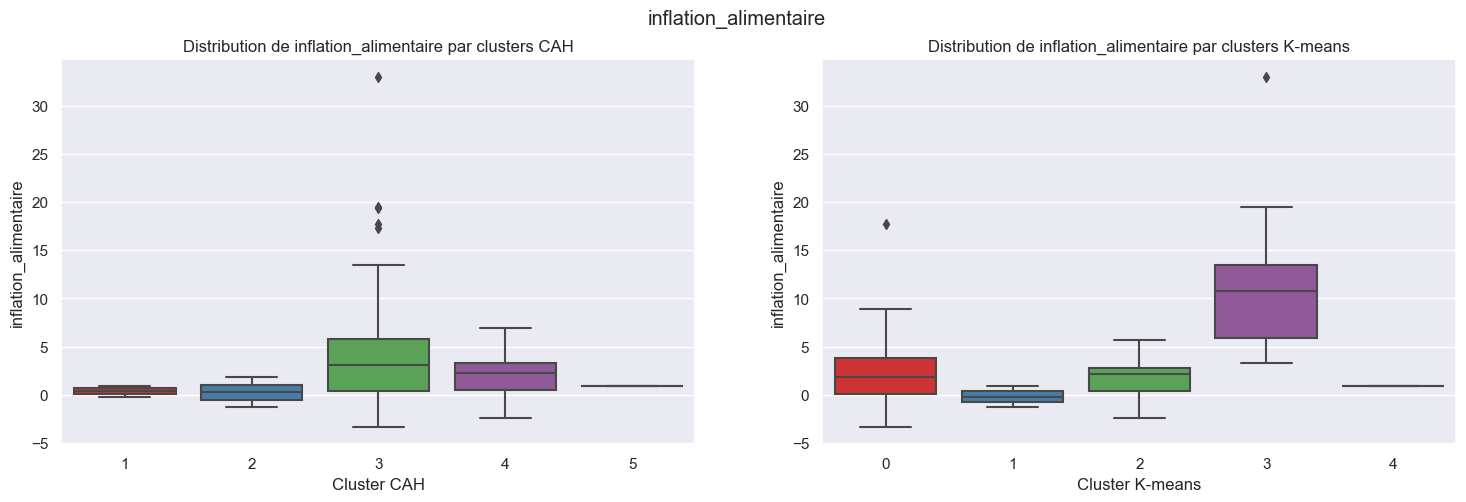

In [347]:
for feature in features:
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    sns.boxplot(
        data=df_result,
        x='cluster_cah',
        y=feature,
        palette='Set1',
        ax=axes[0]
    )
    
    axes[0].set_title(f'Distribution de {feature} par clusters CAH')
    axes[0].set_xlabel('Cluster CAH')
    
    sns.boxplot(
        data=df_result,
        x='cluster_kmeans',
        y=feature,
        palette='Set1',
        ax=axes[1]
    )
    
    axes[1].set_title(f'Distribution de {feature} par clusters K-means')
    axes[1].set_xlabel('Cluster K-means')
    
    plt.suptitle(f'{feature}')

    plt.show()

On observe que cluster 4 obtenu avec la méthode CAH et le cluster 2 obtenu avec la méthode K-means, soit les clusters rassemblant les profils des pays qui nous semblaient les plus intéressants, présentent tout les deux des distributions extrêmements similaies.
- les deux groupes présentent une disponibilité alimentaire par personne moyenne par rapport aux autres clusters
- leurs disponibilités intérieures en viande de volaille est assez faibles si on les compare aux autres groupes/outliers
- pour ce qui est des exportations, quelques outliers sont présents au sein même de ces clusters, mais ils affichent des valeurs assez faibles
- ce sont des importateurs assez importants
- là encore, si on les compare aux autres clusters, leurs niveaux de production est assez faible
- ils ont peu d'habitants
- ce sont les plus stables politiquement
- ce sont les pays situés le plus près de la France
- le pib par habitant y est très élevé
- pour ce qui est de la surface dédiée à l'agriculture, la lecture des distributions est rendue assez compliquée par l'Australie (cluster 5 CAH et 4 K-means) dont la valeur écrase complétement le reste de notre distribution
- les pays les comosants ont subi une inflation alimentaire modérée en 2017

Les deux clusters, le 4 obtenu grâce à la CAH, et le 2 résultant de la méthode des K-means, constituent des groupements de pays qu'il serait pertinent de cibler pour l'exportation de nos poulets.